# Case Study 1 — claim cost prediction with LLM-extracted features

This notebook reads the short free-text descriptions of 3,000 workers' compensation claims with a language model, turns each one into three structured fields — the injured body part, the cause of the injury and the number of body parts injured — and tests whether those fields help a gradient-boosting model predict what each claim will finally cost.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/simonhatzesberger/advanced-genai-actuarial/blob/main/notebooks/03_cs1_claims_text_features/03_cs1_claims_text_features.ipynb)

EAA seminar **E0572 — Advanced Applications of Generative AI in Actuarial Science**, Vilnius, 1–2 October 2026. Lecturer: Dr Simon Hatzesberger.

Repository: [simonhatzesberger/advanced-genai-actuarial](https://github.com/simonhatzesberger/advanced-genai-actuarial)

The case study, its data, its classes and its modelling set-up come from the published article, whose research notebook this one re-implements in the seminar's own style:

> Hatzesberger S, Nonneman I (2026) Advanced applications of generative AI in actuarial science: case studies beyond ChatGPT. *European Actuarial Journal* 16(2):481–523. https://doi.org/10.1007/s13385-026-00464-9

**The business problem.** A claims system holds two kinds of information about every claim: tabular fields — age, wages, dates — that pricing and reserving models have used for decades, and a line of free text typed when the claim was reported, which those models ignore. "CAUGHT BETWEEN GRINDER HAND TOOL CUT RIGHT THUMB" tells an experienced claims handler a good deal about what the claim is likely to cost; a gradient-boosting model cannot read it. A language model can turn it into a few categorical fields, and from there an ordinary model takes over.

**What the notebook does.** `02_llm_techniques` showed that a field typed as a `Literal` — an `enum` in the JSON schema — can only come back as one of its permitted values. This notebook uses that for 3,000 claims. A Pydantic schema whose fields can take only the article's 8 body-part classes and 13 cause classes goes, with the plain `openai` package, to GPT-6 Luna for every claim; the answers then feed the article's gradient-boosting set-up, next to a baseline that sees only the tabular fields.

**Reading it and running it.** Like the other notebooks, this one ships with its outputs, so you can read every answer and every number without a key. Running it needs a key (notebook 00, section 6) for the cells that call GPT-6 Luna live — one claim in full, 500 claims drawn at random plus the fifteen examples of section 2, a stability check, a small comparison of reasoning efforts and a first try of the exercise feature. In the saved run these 774 calls cost USD 0.031 at list prices, or USD 0.111 had none of their input been cached. The extractions for all 3,000 claims — for the model and for the extra exercise — are read from files recorded once, on 22 September 2026, and committed in `data/`; they cost USD 0.082 and USD 0.159 to make. Switch `RUN_FULL_EXTRACTION` or `RUN_FIELD_EXTRACTION` on to repeat them. We do not repeat them in the room: 24 people extracting 3,000 claims each at the same time would share one key's rate limits and learn nothing more than the 500-claim sample teaches. Every cell from section 5 onwards runs without a key. If you run the notebook yourself, GPT-6 Luna's answers, token counts and costs can differ from the saved ones, and the commentary describes the saved run.

## Learning objectives

After working through this notebook you will be able to:

- **explain** what a claim description adds to the tabular fields, and how a language model turns it into model features;
- **fix** the classes of an extraction in advance, in a Pydantic schema with `Literal` fields, and write the definitions and tie-break rules the model needs to choose between them;
- **run** an extraction over thousands of claims: in parallel, with retries, with a cache that survives an interruption, and with a ledger of what it cost;
- **check** an extraction that has no labels to compare against: class distributions, spot checks and repeated runs;
- **train** a gradient-boosting model on a stratified train/test split, and read RMSE, MAE, R² and the miss factor on the log-cost scale;
- **design** a feature of your own and test whether it pays its way with cross-validation and a corrected paired t-test, rather than by trying variants on the test split.

## Contents

1. [Setup](#1-setup)
2. [The data](#2-the-data)
3. [Structured outputs with fixed classes](#3-structured-outputs-with-fixed-classes)
4. [A first look at the extractions](#4-a-first-look-at-the-extractions)
5. [All 3,000 claims](#5-all-3000-claims)
6. [A short introduction to machine learning](#6-a-short-introduction-to-machine-learning)
7. [Predicting the claim cost](#7-predicting-the-claim-cost)
8. [What to take away](#8-what-to-take-away)
9. [Exercises](#9-exercises)

---

## 1 Setup

Two cells, run once. The first lists the packages this notebook uses and their versions. Colab already provides all of them — pandas, NumPy, scikit-learn, SciPy, Matplotlib, `openai` and Pydantic — so nothing is installed; on your own machine, `requirements.txt` in the repository pins them.

The second cell holds everything you might want to change — the number of claims, the size of the live sample, and two switches for the recorded extractions — and then fixes the model and its settings, finds your key without ever printing it, sets up a ledger that records the tokens and the cost of every call that comes back with a response, and defines a small helper that finds the data files.

In [1]:
# Colab ships every package this notebook needs, so nothing is installed here.
# The cell reports the versions, so that every result can be traced to the software that produced it.
import platform
from importlib.metadata import PackageNotFoundError, version

for package in ["pandas", "numpy", "scikit-learn", "scipy", "matplotlib", "openai", "pydantic"]:
    try:
        print(f"[PASS] {package:<13} {version(package)}")
    except PackageNotFoundError:
        print(f"[ATTENTION] {package:<13} is not installed - pip install it at the version in requirements.txt")
print(f"       Python        {platform.python_version()}")

[PASS] pandas        2.2.3
[PASS] numpy         2.4.6
[PASS] scikit-learn  1.6.1
[PASS] scipy         1.18.1
[PASS] matplotlib    3.10.3
[PASS] openai        2.29.0
[PASS] pydantic      2.11.4
       Python        3.13.1


A few words on the model and its settings before the cell that fixes them.

- **`gpt-6-luna`** is the cheapest model of OpenAI's GPT-6 family. It exists only under this alias, not as a dated snapshot, so its behaviour may change without its name changing — one more reason to record the answers once and keep them.
- **Reasoning effort `"none"`.** GPT-6 Luna thinks before it answers unless told otherwise; its default effort is `"medium"`. Sorting a one-line note into a few classes does not need that, so we switch it off. Section 4.5 checks what effort `"low"` would change.
- **`temperature=0`.** GPT-6 Luna accepts a temperature only at reasoning effort `"none"`; at `"low"` or higher it rejects the parameter with an error. We set it to 0 wherever the model accepts it. It makes the answers more repeatable, not identical — section 4.4 measures how repeatable.
- **Prices.** USD 0.10 per million input tokens, USD 0.01 per million cached input tokens, USD 0.125 per million input tokens written to the cache and USD 0.50 per million output tokens: OpenAI's list prices for standard processing, retrieved from its pricing page on 22 September 2026. OpenAI caches the start of a prompt automatically once a request is longer than 1,024 tokens. The requests of sections 3 to 5 are, at about 1,300 tokens, so most calls after the first pay the cached price for the instructions they all begin with; the shorter requests of exercise (a), about 560 tokens, are not cached and pay the full input price. The ledger therefore shows two figures: what a call actually cost, and what it would have cost with no caching at all. The saved run's costs were computed before cache writes were counted and may be too low: by less than USD 0.0001 on the USD 0.031 of its 774 live calls (2,022 uncached input tokens in requests long enough to be cached, at USD 0.025 per million more), by at most USD 0.0011 on the USD 0.0823 of the recorded extraction for the model (44,058 such tokens), and not at all on the USD 0.159 of the recording for the extra exercise, whose requests are too short to be cached.

In [2]:
import hashlib
import json
import os
import random
import re
import threading
import time
import urllib.error
import urllib.request
from concurrent.futures import ThreadPoolExecutor, as_completed
from datetime import datetime, timezone
from pathlib import Path
from typing import Literal, get_args

import matplotlib.pyplot as plt
import numpy as np
import openai
import pandas as pd
from openai import OpenAI
from pydantic import BaseModel, Field

pd.set_option("display.max_colwidth", 90)
pd.set_option("display.width", 200)

# ---- What you may want to change ------------------------------------------------------------------
N_CLAIMS = 3_000              # claims used for the full extraction and for modelling (the file holds 3,000)
N_LIVE = 500                  # claims drawn at random and extracted live in section 4
N_STABILITY = 100             # of those, how many are sent a second time in section 4.4
RUN_FULL_EXTRACTION = False   # True: extract all N_CLAIMS claims live in section 5 instead of reading data/
RUN_FIELD_EXTRACTION = False  # True: the same for the new feature of exercise (a)
MAX_WORKERS = 16              # requests sent in parallel

# ---- The model ------------------------------------------------------------------------------------
MODEL = "gpt-6-luna"          # an alias: there is no dated snapshot
EFFORT = "none"               # reasoning effort: answer directly, without thinking first
TEMPERATURE = 0               # GPT-6 Luna accepts a temperature only at effort "none"

# List prices in USD per million tokens: (input, cached input, cache write, output).
# OpenAI pricing page, standard processing, as retrieved on 22 September 2026.
PRICES_USD_PER_MTOK = {"gpt-6-luna": (0.10, 0.01, 0.125, 0.50)}

SEED = 42       # the random sample, the train/test split and the models, as in the article
EVAL_SEED = 43  # the evaluation folds of exercise (b), as in the article's research notebook

LOCAL_DIR = Path("_local")    # machine-local caches next to this notebook, never committed
DATA_DIR = Path("data")       # the committed data files next to this notebook
RAW_DATA_URL = ("https://raw.githubusercontent.com/simonhatzesberger/advanced-genai-actuarial/main/"
                "notebooks/03_cs1_claims_text_features/data/")
LOCAL_DIR.mkdir(exist_ok=True)


def sampling_options(effort: str = EFFORT) -> dict:
    # GPT-6 Luna accepts a temperature only at reasoning effort "none"; at any other effort it is left out.
    options = {"reasoning": {"effort": effort}}
    if effort == "none":
        options["temperature"] = TEMPERATURE
    return options


def find_api_key(name: str = "OPENAI_API_KEY") -> str | None:
    """Return the key if this environment can see one, otherwise None. Never raises."""
    try:
        from google.colab import userdata  # available on Colab only

        value = userdata.get(name)
        if value:
            return value
    except Exception:
        # Not on Colab, or the secret does not exist, or notebook access is off.
        pass
    return os.environ.get(name) or None


key = find_api_key()
# Retries are handled by call_model() in section 3, so that you can see them; the client itself does not retry.
client = OpenAI(api_key=key, max_retries=0, timeout=120) if key else None


def require_client() -> None:
    # Stop with a clear message, rather than a traceback, when a cell needs the API and no key is visible.
    if client is None:
        raise RuntimeError("No OPENAI_API_KEY is visible - see notebook 00, section 6.")


LEDGER: list[dict] = []  # one row per API call that came back with a response in this session
_LEDGER_LOCK = threading.Lock()


def log_usage(model: str, purpose: str, input_tokens: int, cached_tokens: int = 0, output_tokens: int = 0,
              cache_write_tokens: int = 0) -> dict:
    """Record one paid call in the ledger and return its row, with the cost in USD at the list prices above."""
    price_in, price_cached, price_write, price_out = PRICES_USD_PER_MTOK[model]
    if price_write is None:  # no cache-write price: a write costs the input price
        price_write = price_in
    row = {
        "purpose": purpose,
        "model": model,
        "input_tokens": input_tokens,
        "cached_tokens": cached_tokens,
        "cache_write_tokens": cache_write_tokens,
        "output_tokens": output_tokens,
        "cost_usd": ((input_tokens - cached_tokens - cache_write_tokens) * price_in + cached_tokens * price_cached
                     + cache_write_tokens * price_write + output_tokens * price_out) / 1e6,
        # With no caching at all, every input token pays the input price: nothing is read from or written to the cache.
        "cost_usd_no_cache": (input_tokens * price_in + output_tokens * price_out) / 1e6,
    }
    with _LEDGER_LOCK:
        LEDGER.append(row)
    return row


def spend_report() -> pd.DataFrame:
    """Calls, tokens and cost of everything this session has paid for, by purpose."""
    counts = ["calls", "input_tokens", "cached_tokens", "cache_write_tokens", "output_tokens"]
    costs = ["cost_usd", "cost_usd_no_cache"]
    if not LEDGER:
        print("No paid calls in this session.")
        return pd.DataFrame(columns=counts + costs)
    table = (
        pd.DataFrame(LEDGER)
        .groupby(["purpose", "model"], sort=False)
        .agg(calls=("cost_usd", "size"), input_tokens=("input_tokens", "sum"), cached_tokens=("cached_tokens", "sum"),
             cache_write_tokens=("cache_write_tokens", "sum"), output_tokens=("output_tokens", "sum"),
             cost_usd=("cost_usd", "sum"), cost_usd_no_cache=("cost_usd_no_cache", "sum"))
    )
    table.loc[("total", ""), :] = table.sum()
    table[counts] = table[counts].astype(int)
    return table.round({column: 5 for column in costs})


def short_error(exc: Exception) -> str:
    """One line describing a failed call. It never repeats a key, not even a masked one."""
    text = re.sub(r"sk-[A-Za-z0-9_\-*]{4,}", "sk-***", " ".join(str(exc).split()))
    return f"{type(exc).__name__}: {text[:160]}"


def sha256_of(path: Path) -> str:
    return hashlib.sha256(path.read_bytes()).hexdigest()


def data_file(name: str, expected_sha256: str | None = None) -> Path | None:
    """A committed data file: from data/ next to this notebook, otherwise downloaded once from GitHub into
    _local/data/. The download is written to a temporary name and renamed only once it is complete."""
    for candidate in (DATA_DIR / name, LOCAL_DIR / "data" / name):
        if candidate.exists():
            path = candidate
            break
    else:
        path = LOCAL_DIR / "data" / name
        path.parent.mkdir(parents=True, exist_ok=True)
        partial = path.with_name(name + ".part")
        try:
            with urllib.request.urlopen(RAW_DATA_URL + name, timeout=60) as response:
                partial.write_bytes(response.read())
            os.replace(partial, path)  # atomic: the file appears under its name only once it is complete
        except Exception as exc:
            partial.unlink(missing_ok=True)
            reason = f"HTTP {exc.code}" if isinstance(exc, urllib.error.HTTPError) else type(exc).__name__
            print(f"[ATTENTION] data/{name} is not next to this notebook, and the download from GitHub failed ({reason}).")
            print(f"            Download it by hand from {RAW_DATA_URL + name}")
            print("            and put it into a folder called data/ next to this notebook (in Colab: the folder icon on the")
            print("            left), then run the cell again.")
            return None
    if expected_sha256 is not None and sha256_of(path) != expected_sha256:
        print(f"[ATTENTION] {path.as_posix()} is not byte-identical to the published file (its checksum differs).")
        print("            Delete it and run the cell again to download a fresh copy.")
        return None
    return path


if key:
    print(f"[PASS] A key named OPENAI_API_KEY is visible ({len(key)} characters long).")
    print("       Its value is never printed - not here, not anywhere.")
else:
    print("[ATTENTION] No key named OPENAI_API_KEY is visible to this notebook.")
    print("            The live cells of sections 3, 4.1 to 4.3 and 9 show the recorded answers instead, and the")
    print("            checks of 4.4 and 4.5 are skipped; everything from section 5 on runs without a key.")
    print("            Notebook 00, section 6 explains how to add one.")
print(f"Model            : {MODEL}, reasoning effort '{EFFORT}', temperature {TEMPERATURE}")
print(f"Claims           : {N_CLAIMS:,} for the full extraction and the model; {N_LIVE:,} extracted live in section 4")
print(f"Full extraction  : {'extracted live in section 5' if RUN_FULL_EXTRACTION else 'read from the recording in data/'}")
print(f"Local cache      : {LOCAL_DIR.as_posix()}/ (next to where the notebook runs)")

[PASS] A key named OPENAI_API_KEY is visible (164 characters long).
       Its value is never printed - not here, not anywhere.
Model            : gpt-6-luna, reasoning effort 'none', temperature 0
Claims           : 3,000 for the full extraction and the model; 500 extracted live in section 4
Full extraction  : read from the recording in data/
Local cache      : _local/ (next to where the notebook runs)


---

## 2 The data

### Why it matters for actuaries

Every claims system has a free-text field like this one, and almost every claims model ignores it — not because it is uninformative, but because it cannot be put into a model matrix as it stands. Before asking a language model to read it, it is worth reading some of it yourself: what the notes look like decides what the extraction has to cope with.

The data are the 3,000 workers' compensation claims the article uses. They are synthetic, created by Colin Priest for the Kaggle InClass competition "actuarial-loss-estimation", and the file in `data/` is a byte-identical copy of the one the article's research repository publishes; `data/README.md` has the details and the rights note. Each claim has a few facts about the injured worker, two dates, a short description, and the ultimate incurred cost — the amount the claim finally cost, which we want to predict.

### 2.1 Loading the claims

The cell reads the file, checks that it is byte-identical to the published one, and drops four columns straight away. One is the insurer's initial estimate of each claim's cost: the article's models do not use it, and neither do ours. The other three are the fields the article extracted from the descriptions with its own language model; this notebook extracts its own, from the descriptions alone.

In [3]:
CLAIMS_SHA256 = "c875c29d4a659a5222606d600be2b150f0abd9e6dfa56a64fadd3c1ffb4af44d"
claims_path = data_file("claims_3000.csv", expected_sha256=CLAIMS_SHA256)
if claims_path is None:
    raise FileNotFoundError("claims_3000.csv is needed from here on - see the message above.")

raw = pd.read_csv(claims_path)
# Dropped on load and never used: the insurer's initial cost estimate, which the article's models leave out as well,
# and the three fields the article extracted with its own language model - this notebook extracts its own.
DROPPED = [column for column in raw.columns if re.search("initialincurred", column, flags=re.IGNORECASE)]
DROPPED += ["number_of_body_parts_injured", "main_body_part_injured", "cause_of_injury"]
n_file_columns = raw.shape[1]
claims_file = raw.drop(columns=DROPPED)
del raw  # from here on, only the kept columns exist

if N_CLAIMS > len(claims_file):
    raise ValueError(f"N_CLAIMS is {N_CLAIMS:,}, but the file holds only {len(claims_file):,} claims.")
claims = claims_file.iloc[:N_CLAIMS].reset_index(drop=True)

print(f"[PASS] {claims_path.as_posix()}: {len(claims_file):,} claims, sha256 {CLAIMS_SHA256[:8]}... as published.")
print(f"       {n_file_columns} columns in the file: {len(DROPPED)} dropped on load, {claims_file.shape[1]} kept.")
print(f"       Claims used from here on (N_CLAIMS): {len(claims):,}")

COLUMN_MEANINGS = {
    "ClaimNumber": "identifier of the claim",
    "DateTimeOfAccident": "date and hour of the accident",
    "DateReported": "date on which the claim was reported",
    "Age": "age of the injured worker in years",
    "Gender": "M or F",
    "MaritalStatus": "M married, S single, U unknown",
    "DependentChildren": "number of dependent children",
    "DependentsOther": "number of other dependants",
    "WeeklyWages": "weekly wage",
    "PartTimeFullTime": "P part time, F full time",
    "HoursWorkedPerWeek": "hours worked per week",
    "DaysWorkedPerWeek": "days worked per week",
    "ClaimDescription": "free-text description of the claim",
    "UltimateIncurredClaimCost": "what the claim finally cost: the target",
}
pd.DataFrame(
    [{"column": c, "meaning": COLUMN_MEANINGS[c], "type": str(claims[c].dtype), "missing values": int(claims[c].isna().sum())}
     for c in claims.columns]
).set_index("column")

[PASS] data/claims_3000.csv: 3,000 claims, sha256 c875c29d... as published.
       18 columns in the file: 4 dropped on load, 14 kept.
       Claims used from here on (N_CLAIMS): 3,000


,meaning,type,missing values
column,,,
ClaimNumber,identifier of the claim,object,0
DateTimeOfAccident,date and hour of the accident,object,0
DateReported,date on which the claim was reported,object,0
Age,age of the injured worker in years,int64,0
Gender,M or F,object,0
MaritalStatus,"M married, S single, U unknown",object,2
DependentChildren,number of dependent children,int64,0
DependentsOther,number of other dependants,int64,0
WeeklyWages,weekly wage,float64,0


### 2.2 Eight claims, every column

Here are the first eight claims exactly as the file holds them, with every column that is kept. The two dates carry a time of day: the accident has an hour, the report date is always midnight.

In [4]:
claims.head(8)

,ClaimNumber,DateTimeOfAccident,DateReported,Age,Gender,MaritalStatus,DependentChildren,DependentsOther,WeeklyWages,PartTimeFullTime,HoursWorkedPerWeek,DaysWorkedPerWeek,ClaimDescription,UltimateIncurredClaimCost
0,WC7324004,2000-10-21T08:00:00Z,2000-11-11T00:00:00Z,21,M,S,0,0,481.05,F,40.0,5,LOWER BACK LOWER BACK STRAIN,13291.953330
1,WC7287051,2000-01-10T14:00:00Z,2000-01-16T00:00:00Z,31,M,U,0,0,339.30,F,38.0,5,KNEELING CAUSED ONSET SWELLING BURSITIS RIGHT ELBOW AND ARM,7964.022283
2,WC1844884,1988-02-02T11:00:00Z,1988-03-02T00:00:00Z,43,M,M,0,0,315.30,F,38.0,5,CAUGHT PATIENT STRAIN LEFT MIDDLE FINGER,2123.640727
3,WC3087253,1991-05-14T17:00:00Z,1991-07-26T00:00:00Z,21,M,S,0,0,402.80,F,38.0,5,KNIFE LACERATION LEFT HAND BRUISING TO FACE,649.264964
4,WC9629115,2005-05-19T12:00:00Z,2005-05-28T00:00:00Z,26,M,M,0,0,565.71,F,38.0,5,METAL SPARK ANGLE GRINDER LACERATION RIGHT LOWER LEG,23749.539860
5,WC8119308,2001-01-01T12:00:00Z,2001-07-09T00:00:00Z,35,M,U,0,0,651.00,F,37.5,5,LIFTING STEEL PLATE LACERATED RIGHT HAND,46604.910280
6,WC8116441,2001-06-06T23:00:00Z,2001-07-12T00:00:00Z,17,M,S,0,0,205.00,P,20.0,3,SLIPPED DOWN STAIRS RIGHT KNEE,6578.226053
7,WC6469636,1998-08-14T16:00:00Z,1998-08-27T00:00:00Z,41,F,M,0,0,200.00,P,12.0,2,TRIPPED OVER LUGGAGE STRAINED LOWER BACK PAIN,15673.853720


### 2.3 What the descriptions look like

The descriptions were typed by claims staff, in capitals and in note style. The fifteen below were picked to show the range, each with the ultimate cost of its claim. Read them before reading on: these are what the model will have to make sense of.

In [5]:
SHOWCASE = {
    "WC6161971": "a single word",
    "WC4490127": "two words, and no cause",
    "WC4207125": "the longest description: several body parts, some named twice",
    "WC3753209": "an injury but no mechanism, and a repetition",
    "WC4006878": "cut off in mid-word, and no body part",
    "WC2442897": "a typing error: NEYE",
    "WC3768137": "CARING, most probably for CARRYING",
    "WC5810394": "TROLLY; two body parts and two mechanisms",
    "WC6807703": "the weight of the boxes went with the digits",
    "WC5669864": "an abbreviation: OXY for oxy-acetylene",
    "WC6318440": "local vocabulary: a quad bike and a UTE, a pick-up",
    "WC6947733": "local vocabulary: a redback is an Australian spider",
    "WC7630746": "a mechanism and an outcome; HAND names a tool",
    "WC8639616": "two injuries and no mechanism",
    "WC4878187": "a description that recurs many times",
}

showcase = claims_file.set_index("ClaimNumber").loc[list(SHOWCASE), ["ClaimDescription", "UltimateIncurredClaimCost"]]
with pd.option_context("display.max_colwidth", None):
    display(pd.DataFrame({
        "description": showcase["ClaimDescription"],
        "what it shows": pd.Series(SHOWCASE),
        "ultimate cost": showcase["UltimateIncurredClaimCost"].map("{:,.0f}".format),
    }))

,description,what it shows,ultimate cost
WC6161971,EYE,a single word,"5,780"
WC4490127,INJURED WRIST,"two words, and no cause","27,184"
WC4207125,PLAYING VOLLEYBALL JARRED WRIST STRAINED LEFT SHOULDER STRAIN NECK BACK SHOULDER NECK,"the longest description: several body parts, some named twice","6,107"
WC3753209,LOWER BACK PAIN LOWER BACK STRAIN,"an injury but no mechanism, and a repetition","6,820"
WC4006878,MOTOR VEHICLE ACCIDENT MOTOR VEHICLE ACCI,"cut off in mid-word, and no body part","8,325"
WC2442897,COIL OF STEEL ENTERED EYE IRRITATED LEFT NEYE,a typing error: NEYE,306
WC3768137,CARING A STRAIN RIGHT FOREARM,"CARING, most probably for CARRYING","2,333"
WC5810394,TWISTED KNEE TURNING TO TROLLY STRAINED LEFT SHOULDER,TROLLY; two body parts and two mechanisms,"3,955"
WC6807703,LIFTING KG BOXES STRAIN LOWER BACK STRAIN,the weight of the boxes went with the digits,"7,088"
WC5669864,HIT OXY FLAME JET BURNS FACE,an abbreviation: OXY for oxy-acetylene,"15,008"


Three things stand out. The notes leave out articles and most verbs, and nothing in them is punctuated. Several describe more than one injury, and a few name no cause at all, or no body part. And the spelling is that of a busy claims desk: NEYE, CARING, TROLLY, a word cut off at the end.

The last description is worth a second look. The same words describe several claims, and those claims did not cost the same:

In [6]:
REPEATED = claims_file.loc[claims_file["ClaimNumber"] == "WC4878187", "ClaimDescription"].iloc[0]
same_text = claims_file.loc[claims_file["ClaimDescription"] == REPEATED, "UltimateIncurredClaimCost"].sort_values()
print(f"'{REPEATED}' describes {len(same_text)} claims. Their ultimate costs:")
print("  " + ", ".join(f"{value:,.0f}" for value in same_text))
print(f"From {same_text.min():,.0f} to {same_text.max():,.0f}: the most expensive cost {same_text.max() / same_text.min():.0f} times the cheapest.")

'SLIPPED ON ROLLER TENDONITIS RIGHT SHOULDER' describes 11 claims. Their ultimate costs:
  1,119, 1,665, 1,805, 2,094, 3,305, 4,365, 5,412, 7,085, 7,444, 9,216, 46,541
From 1,119 to 46,541: the most expensive cost 42 times the cheapest.


Eleven claims, one description, and ultimate costs from 1,119 to 46,541: the most expensive cost 42 times the cheapest. Whatever a language model reads from those six words, it reads the same for all eleven claims, so the features built from it cannot tell them apart. A description carries information about the cost of a claim; it cannot carry all of it, and no extraction will change that.

### 2.4 How many different descriptions?

In [7]:
descriptions = claims["ClaimDescription"]
words = descriptions.str.split().str.len()
characters = descriptions.str.len()
print(f"Claims                         : {len(descriptions):,}")
print(f"Distinct descriptions          : {descriptions.nunique():,}")
print(f"Descriptions used more than once: {int((descriptions.value_counts() > 1).sum()):,}, "
      f"covering {int(descriptions.value_counts()[descriptions.value_counts() > 1].sum()):,} claims")
print(f"Words per description          : median {words.median():.0f}, from {words.min()} to {words.max()}")
print(f"Characters per description     : median {characters.median():.0f}, at most {characters.max()}")
print(f"Descriptions with a digit, a lower-case letter or punctuation: {int(descriptions.str.contains(r'[^A-Z ]').sum())}")
print()
print("The descriptions that occur most often:")
descriptions.value_counts().head(8).rename("claims").to_frame()

Claims                         : 3,000
Distinct descriptions          : 2,420
Descriptions used more than once: 206, covering 786 claims
Words per description          : median 7, from 1 to 13
Characters per description     : median 43, at most 85
Descriptions with a digit, a lower-case letter or punctuation: 0

The descriptions that occur most often:


,claims
ClaimDescription,
LIFTING BACK STRAIN LOWER BACK STRAIN,19
HIT AIR HOSE LACERATED LIP,18
SORTING ALUMINIUM BARS STRAIN SHOULDER NECK,17
SLIPPED USING LATHE IN EYE CORNEA,15
LIFTING TYRES LOWER BACK STRAIN,13
FELL DOWN STAIRS BACK SPRAIN,12
PLAYING VOLLEYBALL STRAIN RIGHT ARM RIGHT,12
LEFT LEG SNAKE BITE LEFT ANKLE,11


3,000 claims, but only 2,420 different descriptions: 206 descriptions occur more than once, and between them they cover 786 claims. The notes are short — a median of 7 words, at most 13 words and 85 characters — and they contain nothing but capital letters and spaces: no digits, no punctuation. That is where the weight of the boxes in LIFTING KG BOXES went. Section 5 turns the repeats to advantage by sending each distinct description to the model only once.

### 2.5 The target: the ultimate cost

The left histogram shows the ultimate cost as it is; the right one its natural logarithm, which is what the article's models predict and ours will too. Section 6 explains why.

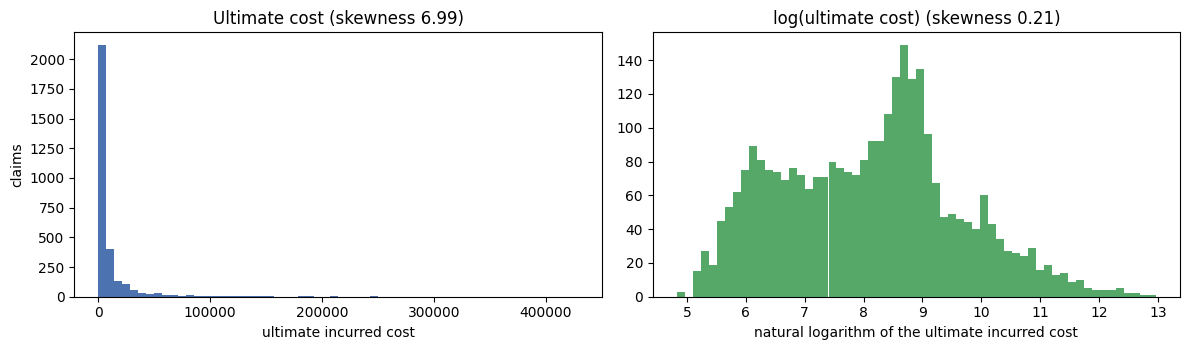

,ultimate cost,log(ultimate cost)
mean,10684.57,8.09
std,26002.05,1.52
min,124.58,4.82
10%,424.64,6.05
50%,3573.16,8.18
90%,24251.16,10.10
max,428383.85,12.97


In [8]:
cost = claims["UltimateIncurredClaimCost"]
log_cost = np.log(cost)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
axes[0].hist(cost, bins=60, color="#4C72B0")
axes[0].set_title(f"Ultimate cost (skewness {cost.skew():.2f})")
axes[0].set_xlabel("ultimate incurred cost")
axes[0].set_ylabel("claims")
axes[1].hist(log_cost, bins=60, color="#55A868")
axes[1].set_title(f"log(ultimate cost) (skewness {log_cost.skew():.2f})")
axes[1].set_xlabel("natural logarithm of the ultimate incurred cost")
fig.tight_layout()
plt.show()

pd.DataFrame(
    {"ultimate cost": cost.describe(percentiles=[0.1, 0.5, 0.9]), "log(ultimate cost)": log_cost.describe(percentiles=[0.1, 0.5, 0.9])}
).drop(index="count").round(2)

The raw cost is right-skewed (skewness 6.99). The median claim cost 3,573, the mean 10,685, and the largest 428,384; nine claims in ten cost less than 24,251. On the log scale the distribution is close to symmetric (skewness 0.21), with a median of 8.18 — which is simply the log of 3,573.

### 2.6 The 18 tabular features of the baseline

The baseline model sees 18 features, all built from the tabular columns as in the article's research notebook, with one correction: six numeric fields as they are; four indicator (0/1) columns for marital status, gender and part-time work, each with one level left out; and eight features built from the two dates. The reporting delay, `Rep_Acc_Diff`, is the number of full days between the accident and the report. That is the correction: the research notebook kept only the first two characters of the time difference, which cut the 198 delays of 100 days or more to two digits (1,021 days became 10). The two missing marital statuses are filled with S, as in the article's research notebook.

In [9]:
NUMERIC_FEATURES = ["Age", "DependentChildren", "DependentsOther", "WeeklyWages", "HoursWorkedPerWeek", "DaysWorkedPerWeek"]
BINARY_FIELDS = {  # field: (all levels, the level left out) - fixed in advance, as in the article
    "MaritalStatus": (("M", "S", "U"), "U"),
    "Gender": (("F", "M"), "F"),
    "PartTimeFullTime": (("F", "P"), "P"),
}
BINARY_FEATURES = [f"{field}_{level}" for field, (levels, left_out) in BINARY_FIELDS.items() for level in levels if level != left_out]
DATE_FEATURES = ["Rep_Acc_Diff", "Accident_Month", "Accident_Year", "Accident_Day", "Accident_Hour",
                 "Reported_Month", "Reported_Year", "Reported_Day"]
BASELINE_FEATURES = NUMERIC_FEATURES + BINARY_FEATURES + DATE_FEATURES


def tabular_features(frame: pd.DataFrame) -> pd.DataFrame:
    """The 18 baseline features, built from the tabular columns only."""
    out = frame[NUMERIC_FEATURES].copy()
    values = {"MaritalStatus": frame["MaritalStatus"].fillna("S"),  # two missing values, as in the research notebook
              "Gender": frame["Gender"], "PartTimeFullTime": frame["PartTimeFullTime"]}
    for field, (levels, left_out) in BINARY_FIELDS.items():
        unexpected = set(values[field]) - set(levels)
        if unexpected:
            raise ValueError(f"{field} has values outside {levels}: {sorted(unexpected)}")
        for level in levels:
            if level != left_out:
                out[f"{field}_{level}"] = (values[field] == level).astype(int)
    accident = pd.to_datetime(frame["DateTimeOfAccident"])
    reported = pd.to_datetime(frame["DateReported"])
    out["Rep_Acc_Diff"] = (reported - accident).dt.days  # full days from the accident to the report
    out["Accident_Month"], out["Accident_Year"] = accident.dt.month, accident.dt.year
    out["Accident_Day"], out["Accident_Hour"] = accident.dt.day, accident.dt.hour
    out["Reported_Month"], out["Reported_Year"], out["Reported_Day"] = reported.dt.month, reported.dt.year, reported.dt.day
    return out[BASELINE_FEATURES]


X_baseline = tabular_features(claims)

FEATURE_MEANINGS = {
    "Age": "age in years", "DependentChildren": "dependent children", "DependentsOther": "other dependants",
    "WeeklyWages": "weekly wage", "HoursWorkedPerWeek": "hours per week", "DaysWorkedPerWeek": "days per week",
    "MaritalStatus_M": "1 if married", "MaritalStatus_S": "1 if single", "Gender_M": "1 if male",
    "PartTimeFullTime_F": "1 if full time", "Rep_Acc_Diff": "reporting delay in full days",
    "Accident_Month": "month of the accident", "Accident_Year": "year of the accident",
    "Accident_Day": "day of the month of the accident", "Accident_Hour": "hour of the accident",
    "Reported_Month": "month of the report", "Reported_Year": "year of the report",
    "Reported_Day": "day of the month of the report",
}
print(f"[PASS] {X_baseline.shape[1]} baseline features for {len(X_baseline):,} claims, no missing values: {not X_baseline.isna().any().any()}")
pd.DataFrame({
    "meaning": pd.Series(FEATURE_MEANINGS),
    "min": X_baseline.min(),
    "median": X_baseline.median(),
    "max": X_baseline.max(),
}).loc[BASELINE_FEATURES]

[PASS] 18 baseline features for 3,000 claims, no missing values: True


,meaning,min,median,max
Age,age in years,14.0,32.0,71.00
DependentChildren,dependent children,0.0,0.0,5.00
DependentsOther,other dependants,0.0,0.0,2.00
WeeklyWages,weekly wage,1.0,388.0,2441.24
HoursWorkedPerWeek,hours per week,0.0,38.0,640.00
DaysWorkedPerWeek,days per week,1.0,5.0,7.00
MaritalStatus_M,1 if married,0.0,0.0,1.00
MaritalStatus_S,1 if single,0.0,0.0,1.00
Gender_M,1 if male,0.0,1.0,1.00
PartTimeFullTime_F,1 if full time,0.0,1.0,1.00


The table also shows that the synthetic data are not always tidy: a 640-hour working week, a weekly wage of 1, a worker aged 14. The article's models use such values as they are, and so do ours. The reporting delay runs from −1 — a report dated midnight on the day of the accident, a few hours before the accident's recorded hour — to 1,021 days, with a median of 22 days. The accidents happened between 1988 and 2005.

Not one of these 18 features knows what happened to the worker. That is the gap the descriptions can fill.

---

## 3 Structured outputs with fixed classes

### Why it matters for actuaries

A model matrix needs categories, not sentences. Ask a language model for "the injured body part" in free text and you get LOWER BACK, BACK and LOW BACK — one body region in three spellings, and the next run brings new ones. The article took that route: its model returned free-text strings, which were mapped to categories afterwards. Here the classes are fixed in advance, in the schema itself, and fixing a set of permitted values in advance is what structured outputs are good at: the provider constrains the answer so that nothing else can come back.

Three decisions are yours and not the model's: which classes exist, what each one means, and which one wins when a note fits two. This section makes all three explicit.

### 3.1 The classes

We keep the article's class names — 8 for the body part, 13 for the cause — so that the results stay comparable with the article's. Each class gets a short definition in plain language, and the definitions below are what the model is told.

In [10]:
BODY_CLASSES = {
    "HEAD_FACE": "head, face, forehead, scalp, ear, nose, jaw, mouth, lip, chin, cheek, teeth",
    "EYES": "eye or eyes, cornea, eyelid",
    "TORSO": "back (upper, middle, lower, lumbar, thoracic), chest, ribs, side, abdomen, stomach, groin, hernia, "
             "buttock, coccyx, internal organs",
    "UPPER_EXTREMITY": "shoulder, rotator cuff, arm, upper arm, biceps, elbow, forearm, wrist",
    "HAND_FINGERS": "hand, palm, knuckle, thumb, finger or fingers, fingertip",
    "LOWER_EXTREMITY": "hip, thigh, leg, knee, kneecap, shin, calf, ankle, foot or feet, heel, toe or toes",
    "NECK": "neck, cervical spine, whiplash",
    "OTHER": "skin, muscles or tendons with no location, the whole body, or no body part stated",
}
CAUSE_CLASSES = {
    "LIFTING_CARRYING": "lifting, carrying, holding, stacking, loading or unloading, pushing, pulling, moving or "
                        "transferring a load or a person, shovelling",
    "IMPACT": "struck by or against something, hit, bumped, knocked, kicked, a flying or falling object, a collision "
              "that is not a road accident, something that burst or exploded",
    "FALL_SLIP_TRIP": "fall, slip, trip, stumble, lost footing, a fall from a height, stairs or a ladder, something "
                      "that gave way underfoot, landing awkwardly",
    "STRAIN_SPRAIN": "bending, twisting, turning awkwardly, reaching or overreaching, stretching, kneeling, "
                     "repetitive or overuse movement",
    "LACERATION": "cut or stabbed by a sharp object (knife, blade, glass, sheet metal), slicing, grinding, scraping, "
                  "scratching, piercing",
    "CHEMICAL_BURN": "heat, flame, hot liquid, steam, welding flash, sparks, chemicals, acid or another irritant, "
                     "including splashes and sprays",
    "COMPRESSION": "caught in or between, jammed, crushed, pinched, trapped, squashed",
    "CONTACT": "a foreign body or splinter entering the eye or skin, electric shock, a bite or sting, an assault "
               "or attack by a person or an animal, contact with a harmful substance",
    "ERGONOMIC": "an ordinary work activity or tool use with no other mechanism (using, operating, typing, sewing, "
                 "cleaning, sweeping, drilling, hammering, installing, packing)",
    "WALKING": "walking, stepping, standing, running, jumping, climbing, getting in or out of something, with no "
               "fall, slip or trip stated",
    "DRIVING": "driving or riding in a vehicle, a motor vehicle or road accident",
    "MEDICAL": "a medical condition is named but no mechanism at all (fracture, tendonitis, bursitis, hernia, "
               "infection, amputation, fainting, bruising)",
    "OTHER": "a mechanism that fits none of the classes above, or a description that states no cause",
}

with pd.option_context("display.max_colwidth", None):
    display(pd.DataFrame({"body part class": list(BODY_CLASSES), "what it covers": list(BODY_CLASSES.values())})
            .set_index("body part class"))
    display(pd.DataFrame({"cause class": list(CAUSE_CLASSES), "what it covers": list(CAUSE_CLASSES.values())})
            .set_index("cause class"))

,what it covers
body part class,
HEAD_FACE,"head, face, forehead, scalp, ear, nose, jaw, mouth, lip, chin, cheek, teeth"
EYES,"eye or eyes, cornea, eyelid"
TORSO,"back (upper, middle, lower, lumbar, thoracic), chest, ribs, side, abdomen, stomach, groin, hernia, buttock, coccyx, internal organs"
UPPER_EXTREMITY,"shoulder, rotator cuff, arm, upper arm, biceps, elbow, forearm, wrist"
HAND_FINGERS,"hand, palm, knuckle, thumb, finger or fingers, fingertip"
LOWER_EXTREMITY,"hip, thigh, leg, knee, kneecap, shin, calf, ankle, foot or feet, heel, toe or toes"
NECK,"neck, cervical spine, whiplash"
OTHER,"skin, muscles or tendons with no location, the whole body, or no body part stated"


,what it covers
cause class,
LIFTING_CARRYING,"lifting, carrying, holding, stacking, loading or unloading, pushing, pulling, moving or transferring a load or a person, shovelling"
IMPACT,"struck by or against something, hit, bumped, knocked, kicked, a flying or falling object, a collision that is not a road accident, something that burst or exploded"
FALL_SLIP_TRIP,"fall, slip, trip, stumble, lost footing, a fall from a height, stairs or a ladder, something that gave way underfoot, landing awkwardly"
STRAIN_SPRAIN,"bending, twisting, turning awkwardly, reaching or overreaching, stretching, kneeling, repetitive or overuse movement"
LACERATION,"cut or stabbed by a sharp object (knife, blade, glass, sheet metal), slicing, grinding, scraping, scratching, piercing"
CHEMICAL_BURN,"heat, flame, hot liquid, steam, welding flash, sparks, chemicals, acid or another irritant, including splashes and sprays"
COMPRESSION,"caught in or between, jammed, crushed, pinched, trapped, squashed"
CONTACT,"a foreign body or splinter entering the eye or skin, electric shock, a bite or sting, an assault or attack by a person or an animal, contact with a harmful substance"
ERGONOMIC,"an ordinary work activity or tool use with no other mechanism (using, operating, typing, sewing, cleaning, sweeping, drilling, hammering, installing, packing)"


The class names are the article's; the definitions are this notebook's own, written for the model, and all it is told about the classes. OTHER is the safety valve in both lists. Without it, the schema would force the model to pick a real class for a note that supports none, and the answer would look more certain than the note.

### 3.2 The schema

The schema turns the two lists into `Literal` types: `body_part_category` can be one of the 8 body-part classes and nothing else, `cause_of_injury_category` one of the 13 cause classes. The count is an integer that may not be negative (`ge=0`). The field names are the article's.

In [11]:
BodyPart = Literal[tuple(BODY_CLASSES)]  # the 8 class names, and nothing else
Cause = Literal[tuple(CAUSE_CLASSES)]    # the 13 class names, and nothing else


class ClaimFeatures(BaseModel):
    body_part_category: BodyPart = Field(description="Class of the primary injured body part")
    cause_of_injury_category: Cause = Field(description="Class of the mechanism that caused the injury")
    number_of_body_parts_injured: int = Field(ge=0, description="Number of distinct injured body parts")


FIELDS = list(ClaimFeatures.model_fields)
print(json.dumps(ClaimFeatures.model_json_schema(), indent=2))

{
  "properties": {
    "body_part_category": {
      "description": "Class of the primary injured body part",
      "enum": [
        "HEAD_FACE",
        "EYES",
        "TORSO",
        "UPPER_EXTREMITY",
        "HAND_FINGERS",
        "LOWER_EXTREMITY",
        "NECK",
        "OTHER"
      ],
      "title": "Body Part Category",
      "type": "string"
    },
    "cause_of_injury_category": {
      "description": "Class of the mechanism that caused the injury",
      "enum": [
        "LIFTING_CARRYING",
        "IMPACT",
        "FALL_SLIP_TRIP",
        "STRAIN_SPRAIN",
        "LACERATION",
        "CHEMICAL_BURN",
        "COMPRESSION",
        "CONTACT",
        "ERGONOMIC",
        "WALKING",
        "DRIVING",
        "MEDICAL",
        "OTHER"
      ],
      "title": "Cause Of Injury Category",
      "type": "string"
    },
    "number_of_body_parts_injured": {
      "description": "Number of distinct injured body parts",
      "minimum": 0,
      "title": "Number Of Body 

This JSON schema is what travels with every request; the model never sees the Python class. The `enum` lists are the contract the provider enforces: an answer outside them cannot come back. So there are no mapping rules to write and no stray spellings to map afterwards — and every claim is guaranteed to land in exactly one of the classes the model matrix of section 7 expects.

### 3.3 The instructions

The schema says *which* values are allowed; the instructions say *when* each one applies. They are assembled from the two class lists above plus the tie-break rules: which body part counts as primary, which cause wins when a note names both a mechanism and its outcome, and how to count. They are printed in full — this is what the model reads before every description.

In [12]:
def class_lines(classes: dict) -> str:
    return "\n".join(f"- {name}: {definition}." for name, definition in classes.items())


INSTRUCTIONS = f"""You classify workers' compensation claim descriptions. A description is a short note in capitals: \
articles and verbs are often left out, words can be repeated, misspelt or cut off at the end, and numbers have been \
removed. Read a misspelt or cut-off word as the word that is clearly meant (TROLLY is trolley, a final ACCI is \
accident). Use only what the description says, and never guess beyond it.

Return three fields.

1. body_part_category: the class of the PRIMARY injured body part.
{class_lines(BODY_CLASSES)}
Which body part is primary:
- Only a body part that is injured counts. A word that names a tool, an object or a place (HAND TOOL, FOOT PEDAL, \
BACK OF THE TRUCK) is not an injured body part.
- If several body parts are injured, take the one the description names first as injured.
- Left or right does not change the class.

2. cause_of_injury_category: the class of the MECHANISM, the event or activity that caused the injury.
{class_lines(CAUSE_CLASSES)}
Which cause wins:
- The mechanism wins over the outcome. LIFTING BOX STRAINED BACK is LIFTING_CARRYING, not STRAIN_SPRAIN. CAUGHT \
FINGER IN DOOR CUT FINGER is COMPRESSION, not LACERATION. SLIPPED ON FLOOR FRACTURED WRIST is FALL_SLIP_TRIP, not \
MEDICAL.
- A strain or sprain with no other mechanism is STRAIN_SPRAIN; a cut with no other mechanism is LACERATION; a burn \
with no other mechanism is CHEMICAL_BURN.
- If several mechanisms are named, take the first one that led to the injury.
- If the cause is not stated or not clear, choose OTHER. A bare INJURED, PAIN or SORE is not a cause.

3. number_of_body_parts_injured: the number of distinct injured body parts.
- A body part repeated in the description counts once (LOWER BACK ... LOWER BACK STRAIN is 1).
- Left and right of the same part count as two; a plural such as KNEES or BOTH HANDS counts as two.
- A word that names a tool, an object or a place does not count.
- 0 if the description names no injured body part.
"""

print(INSTRUCTIONS)
print(f"--- {len(INSTRUCTIONS):,} characters, {len(INSTRUCTIONS.split()):,} words")

You classify workers' compensation claim descriptions. A description is a short note in capitals: articles and verbs are often left out, words can be repeated, misspelt or cut off at the end, and numbers have been removed. Read a misspelt or cut-off word as the word that is clearly meant (TROLLY is trolley, a final ACCI is accident). Use only what the description says, and never guess beyond it.

Return three fields.

1. body_part_category: the class of the PRIMARY injured body part.
- HEAD_FACE: head, face, forehead, scalp, ear, nose, jaw, mouth, lip, chin, cheek, teeth.
- EYES: eye or eyes, cornea, eyelid.
- TORSO: back (upper, middle, lower, lumbar, thoracic), chest, ribs, side, abdomen, stomach, groin, hernia, buttock, coccyx, internal organs.
- UPPER_EXTREMITY: shoulder, rotator cuff, arm, upper arm, biceps, elbow, forearm, wrist.
- HAND_FINGERS: hand, palm, knuckle, thumb, finger or fingers, fingertip.
- LOWER_EXTREMITY: hip, thigh, leg, knee, kneecap, shin, calf, ankle, foot or 

The three example notes in the cause rules are made up for the instructions; none of them is a claim from the data. The rules themselves are choices, and other choices would be defensible — the most serious injury instead of the first one named, say, or the outcome instead of the mechanism. What matters is that they are written down, applied the same way to every claim, and can be changed in one place.

### 3.4 One claim, shown in full

`call_model()` is the whole extraction for one description: the instructions go in as `instructions`, the description as `input`, the schema as `text_format` — the `client.responses.parse` call of `02_llm_techniques`. Around it sit three safeguards. A rate limit or a passing network or server problem is retried after a pause that doubles every time (2, 4, 8, … seconds, with a little random jitter, so that parallel calls do not retry in step), and a reply that cannot be read is requested once more. A call that still fails is returned as a failure — an **API error** if the request never produced an answer, a **failed answer** if the model replied but nothing usable came back — and never as an answer. And every successful call is written to the ledger.

The claim is the one quoted at the top of the notebook: a mechanism (CAUGHT BETWEEN), an outcome (CUT) and a word, HAND, that names a tool rather than an injury.

In [13]:
RETRYABLE = (openai.RateLimitError, openai.APIConnectionError, openai.APITimeoutError, openai.InternalServerError)
MAX_ATTEMPTS = 6
NO_CREDIT = {"flag": False}  # set once the key reports that it has no credit left


def usage_counts(usage) -> tuple[int, int, int, int, int]:
    # (input, cached input, cache-write, output, reasoning) tokens from a Responses API usage object.
    # cache_write_tokens is a typed field in openai 3.x and an untyped extra one in 2.x: getattr reads both, 0 if absent.
    input_details = getattr(usage, "input_tokens_details", None)
    output_details = getattr(usage, "output_tokens_details", None)
    cached = (getattr(input_details, "cached_tokens", 0) or 0) if input_details else 0
    cache_write = (getattr(input_details, "cache_write_tokens", 0) or 0) if input_details else 0
    reasoning = (getattr(output_details, "reasoning_tokens", 0) or 0) if output_details else 0
    return usage.input_tokens, cached, cache_write, usage.output_tokens, reasoning


def call_model(text: str, schema=None, instructions: str | None = None, purpose: str = "extraction",
               effort: str = EFFORT, model: str = MODEL) -> dict:
    """One structured extraction. Never raises: a failed call comes back as a failure, never as an answer."""
    schema, instructions = schema or ClaimFeatures, instructions or INSTRUCTIONS
    record = {"text": text, "answer": None, "parsed": None, "raw_json": None, "error": None, "api_error": False,
              "retries": 0, "input_tokens": 0, "cached_tokens": 0, "cache_write_tokens": 0, "output_tokens": 0,
              "reasoning_tokens": 0, "cost_usd": 0.0, "cost_usd_no_cache": 0.0, "seconds": 0.0}
    if client is None or NO_CREDIT["flag"]:
        record.update(error="no API key" if client is None else "no credit left on this key", api_error=True)
        return record
    started = time.time()
    for attempt in range(1, MAX_ATTEMPTS + 1):
        try:
            response = client.responses.parse(model=model, instructions=instructions, input=text,
                                              text_format=schema, **sampling_options(effort))
            break
        except RETRYABLE as exc:  # rate limit, network or server trouble: wait, then try again
            if getattr(exc, "code", None) == "insufficient_quota":  # no credit left: waiting would not help
                NO_CREDIT["flag"] = True
                record.update(error="no credit left on this key", api_error=True, seconds=round(time.time() - started, 2))
                return record
            if attempt == MAX_ATTEMPTS:
                record.update(error=short_error(exc), api_error=True, seconds=round(time.time() - started, 2))
                return record
            record["retries"] += 1
            time.sleep(2 ** attempt + random.uniform(0, 1))
        except openai.APIError as exc:  # the request itself was refused: a bad parameter, a wrong key, a model the key cannot use
            record.update(error=short_error(exc), api_error=True, seconds=round(time.time() - started, 2))
            return record
        except Exception as exc:  # the model replied, but the reply could not be used: one more try, then give up
            if attempt >= 2:
                record.update(error=short_error(exc), seconds=round(time.time() - started, 2))
                return record
            record["retries"] += 1
    tokens_in, cached, cache_write, tokens_out, reasoning = usage_counts(response.usage)
    row = log_usage(model, purpose, tokens_in, cached, tokens_out, cache_write_tokens=cache_write)
    record.update(raw_json=response.output_text, input_tokens=tokens_in, cached_tokens=cached,
                  cache_write_tokens=cache_write, output_tokens=tokens_out, reasoning_tokens=reasoning,
                  cost_usd=row["cost_usd"], cost_usd_no_cache=row["cost_usd_no_cache"],
                  seconds=round(time.time() - started, 2))
    if response.output_parsed is None:
        record["error"] = "no parsed answer - the model may have refused or been cut off"
    else:
        record["parsed"] = response.output_parsed
        record["answer"] = response.output_parsed.model_dump()
    return record


_RECORDED: dict = {}


def recorded_extraction(name: str = "luna_extraction_3000.csv") -> pd.DataFrame | None:
    """The recorded answers of section 5, by claim number - used when no key is visible."""
    if name not in _RECORDED:
        path = data_file(name)
        _RECORDED[name] = pd.read_csv(path).set_index("claim_number") if path is not None else None
    return _RECORDED[name]


DEMO_CLAIM = "WC7630746"
demo_text = claims_file.set_index("ClaimNumber").loc[DEMO_CLAIM, "ClaimDescription"]

print("THE REQUEST")
print(f"  model        : {MODEL}")
print(f"  options      : {sampling_options()}")
print(f"  instructions : the {len(INSTRUCTIONS):,} characters printed above")
print(f"  input        : {demo_text!r}")
print("  text_format  : ClaimFeatures - sent as the JSON schema printed above")
print()
demo = call_model(demo_text, purpose="one claim in full")
if demo["answer"] is not None:
    print("THE RAW JSON, exactly as the model returned it:")
    print(f"  {demo['raw_json']}")
    print()
    print("THE SAME ANSWER after Pydantic has parsed and validated it:")
    print(f"  {demo['parsed']!r}")
    print()
    print(f"Tokens : {demo['input_tokens']:,} in ({demo['cached_tokens']:,} of them cached), "
          f"{demo['output_tokens']:,} out ({demo['reasoning_tokens']:,} of them reasoning)")
    print(f"Cost   : USD {demo['cost_usd']:.6f} (USD {demo['cost_usd_no_cache']:.6f} with no caching)"
          f"   Time: {demo['seconds']:.1f} seconds   Retries: {demo['retries']}")
else:
    print(f"[ATTENTION] No live answer ({demo['error']}).")
    recorded = recorded_extraction()
    if recorded is not None:
        print("            The answer recorded for this claim in data/luna_extraction_3000.csv:")
        print(f"            {recorded.loc[DEMO_CLAIM, FIELDS].to_dict()}")

THE REQUEST
  model        : gpt-6-luna
  options      : {'reasoning': {'effort': 'none'}, 'temperature': 0}
  instructions : the 4,345 characters printed above
  input        : 'CAUGHT BETWEEN GRINDER HAND TOOL CUT RIGHT THUMB'
  text_format  : ClaimFeatures - sent as the JSON schema printed above



THE RAW JSON, exactly as the model returned it:
  {"body_part_category":"HAND_FINGERS","cause_of_injury_category":"COMPRESSION","number_of_body_parts_injured":1}

THE SAME ANSWER after Pydantic has parsed and validated it:
  ClaimFeatures(body_part_category='HAND_FINGERS', cause_of_injury_category='COMPRESSION', number_of_body_parts_injured=1)

Tokens : 1,314 in (1,311 of them cached), 37 out (0 of them reasoning)
Cost   : USD 0.000032 (USD 0.000150 with no caching)   Time: 2.2 seconds   Retries: 0


All three rules of section 3.3 are at work in that one line. The primary body part is the thumb, so HAND_FINGERS — and HAND in HAND TOOL was not counted, so the count is 1. The cause is the mechanism, CAUGHT BETWEEN (COMPRESSION), not its outcome, CUT (LACERATION). The raw JSON has exactly the three fields of the schema, and Pydantic turns it into a `ClaimFeatures` object without complaint.

The call used 1,314 input tokens and 37 output tokens, none of them for reasoning. 1,311 of the input tokens were billed at the cached price, because the same request had been sent shortly before, in an earlier run of this notebook. So it cost USD 0.000032; with no caching it would have cost USD 0.000150 — 1.5 US cents per hundred claims. On your own first run the first call pays the full price, and the calls after it still find the instructions in the cache, since every request starts with the same instructions.

---

## 4 A first look at the extractions

### Why it matters for actuaries

Before paying for 3,000 extractions and building a model on them, look at a few hundred. There are no labels to score the answers against here, so the checks are the ones an actuary would make on any new data source: do the answers look right when you read them next to the notes, are the classes used in sensible proportions, and does the model give the same answer when it is asked twice?

### 4.1 Five hundred claims, live

`extract_many()` sends a list of descriptions to the model in parallel, `MAX_WORKERS` at a time, each through `call_model()`, and sends each distinct description only once. The sample is `N_LIVE` = 500 claims drawn at random (seed 42), plus the fifteen descriptions of section 2.3. If the whole room runs this cell at the same moment, some requests will hit the key's rate limit and be retried after a pause; the cell reports how many.

In [14]:
def extract_many(texts, schema=None, instructions: str | None = None, purpose: str = "extraction",
                 effort: str = EFFORT, cache_path: Path | None = None, workers: int = MAX_WORKERS) -> tuple[dict, dict]:
    """Extract every distinct text once, in parallel. Returns ({text: record}, summary).

    With a cache_path, every answer is appended to that file the moment it arrives, and texts already in the file
    are not sent again - so an interrupted or rate-limited run resumes where it stopped. Failures are never cached."""
    distinct = list(dict.fromkeys(texts))
    records: dict = {}
    if cache_path is not None and Path(cache_path).exists():
        for line in Path(cache_path).read_text(encoding="utf-8").splitlines():
            try:
                entry = json.loads(line)
                records[entry["text"]] = {**entry, "error": None, "api_error": False, "from_cache": True}
            except (json.JSONDecodeError, KeyError):
                continue  # a line cut off by an interruption: that text is simply sent again
    todo = [text for text in distinct if text not in records]
    lock, started, fresh = threading.Lock(), time.time(), []

    def work(text: str) -> dict:
        record = call_model(text, schema, instructions, purpose, effort)
        if cache_path is not None and record["answer"] is not None:
            keep = ["text", "answer", "input_tokens", "cached_tokens", "cache_write_tokens", "output_tokens",
                    "reasoning_tokens", "cost_usd", "cost_usd_no_cache", "seconds", "retries"]
            with lock, open(cache_path, "a", encoding="utf-8", newline="\n") as handle:
                handle.write(json.dumps({k: record[k] for k in keep}) + "\n")
        return record

    if todo:
        with ThreadPoolExecutor(max_workers=workers) as pool:
            futures = {pool.submit(work, text): text for text in todo}
            try:
                for done, future in enumerate(as_completed(futures), start=1):
                    record = future.result()
                    records[futures[future]] = record
                    fresh.append(record)
                    if len(todo) >= 1_000 and done % 500 == 0:
                        failed = sum(r["answer"] is None for r in fresh)
                        print(f"  {done:,} of {len(todo):,} sent, {failed} failed so far, {time.time() - started:.0f} s")
            except KeyboardInterrupt:  # Stop: cancel the requests still queued instead of sending them all
                pool.shutdown(wait=False, cancel_futures=True)
                print("[ATTENTION] Interrupted: the requests still queued were cancelled"
                      + ("; the answers so far are kept in the local cache." if cache_path is not None else "."))
                raise
    total = lambda field: sum(r.get(field, 0) or 0 for r in fresh)  # noqa: E731
    summary = {
        "texts": len(distinct), "from_cache": len(distinct) - len(todo), "calls": len(todo),
        "answers": sum(records[text]["answer"] is not None for text in distinct),
        "api_errors": sum(r["api_error"] for r in fresh),
        "failed_answers": sum(r["answer"] is None and not r["api_error"] for r in fresh),
        "retries": total("retries"), "input_tokens": total("input_tokens"), "cached_tokens": total("cached_tokens"),
        "output_tokens": total("output_tokens"), "reasoning_tokens": total("reasoning_tokens"),
        "cost_usd": total("cost_usd"), "cost_usd_no_cache": total("cost_usd_no_cache"),
        "seconds": round(time.time() - started, 1),
        "first_error": next((r["error"] for r in fresh if r["api_error"]), None),
        "failures": [(r["text"], r["error"]) for r in fresh if r["answer"] is None],
    }
    return {text: records[text] for text in distinct}, summary


def report_run(summary: dict, where: str) -> None:
    """Calls, tokens, cost and time of one extract_many() run - and API errors separately from failed answers."""
    print(f"{where}: {summary['texts']:,} distinct descriptions; {summary['calls']:,} sent now, "
          f"{summary['from_cache']:,} read from the local cache.")
    if summary["calls"]:
        print(f"  Tokens : {summary['input_tokens']:,} in ({summary['cached_tokens']:,} cached), "
              f"{summary['output_tokens']:,} out")
        print(f"  Cost   : USD {summary['cost_usd']:.4f} (USD {summary['cost_usd_no_cache']:.4f} with no caching)")
        print(f"  Time   : {summary['seconds']:.0f} seconds with up to {MAX_WORKERS} requests in parallel; "
              f"{summary['retries']} {'retry' if summary['retries'] == 1 else 'retries'}")
    if summary["api_errors"]:
        print(f"[ATTENTION] {summary['api_errors']} call(s) failed with an API error, not a wrong answer "
              f"(first: {summary['first_error']}). They count as failures"
              + ("." if NO_CREDIT["flag"] else "; run the cell again to retry them."))
    if NO_CREDIT["flag"]:
        print("[ATTENTION] The key has no credit left (insufficient_quota): the remaining calls were not sent.")
    if summary["failed_answers"]:
        print(f"[ATTENTION] {summary['failed_answers']} call(s) reached the model but brought back no usable answer, "
              "even when tried again. They count as failures, not as answers:")
    for text, error in summary["failures"][:3]:
        print(f"            {text!r}: {error}")
    if summary["answers"] == summary["texts"]:
        print(f"[PASS] All {summary['texts']:,} descriptions have an answer.")


def recorded_records(texts) -> dict:
    """{text: record} from the recording of section 5 - the fallback when no key is visible."""
    recorded = recorded_extraction()
    if recorded is None:
        return {text: {"answer": None} for text in texts}
    by_text = claims_file.set_index("ClaimNumber")["ClaimDescription"]
    answers = recorded[FIELDS].join(by_text).drop_duplicates("ClaimDescription").set_index("ClaimDescription")
    return {text: {"answer": answers.loc[text, FIELDS].to_dict() if text in answers.index else None} for text in texts}


def answers_for(texts, records: dict) -> pd.DataFrame:
    """The three fields for a list of descriptions, one row each; a failed extraction gives an empty row."""
    empty = {field: None for field in FIELDS}
    return pd.DataFrame([records[text]["answer"] or empty for text in texts], columns=FIELDS)


sample = claims.sample(n=min(N_LIVE, len(claims)), random_state=SEED)
showcase_texts = showcase["ClaimDescription"]
live_texts = list(dict.fromkeys(list(sample["ClaimDescription"]) + list(showcase_texts)))
LIVE = client is not None

if LIVE:
    live_records, live_summary = extract_many(live_texts, purpose="first look (section 4)")
    report_run(live_summary, "Section 4")
    if live_summary["calls"] and not live_summary["answers"]:  # every call failed: a wrong key, or no credit left
        LIVE = False
        live_records = recorded_records(live_texts)
        print("[ATTENTION] Not one live answer: this section shows the recorded answers instead, and the later")
        print("            live cells behave as if no key were visible.")
else:
    live_records = recorded_records(live_texts)
    print(f"[ATTENTION] No key: the {len(live_texts):,} descriptions of this section show the answers recorded in")
    print("            data/luna_extraction_3000.csv instead of live ones.")
print(f"The sample: {len(sample):,} claims with {sample['ClaimDescription'].nunique():,} distinct descriptions, "
      f"plus the {len(showcase_texts)} of section 2.3.")

Section 4: 473 distinct descriptions; 473 sent now, 0 read from the local cache.
  Tokens : 622,621 in (621,202 cached), 18,114 out
  Cost   : USD 0.0154 (USD 0.0713 with no caching)
  Time   : 42 seconds with up to 16 requests in parallel; 0 retries
[PASS] All 473 descriptions have an answer.
The sample: 500 claims with 462 distinct descriptions, plus the 15 of section 2.3.


473 calls: the 462 distinct descriptions of the sample and the fifteen of section 2.3, four of which also occur in the sample. All 473 came back with an answer, with no retries, in 42 seconds. They cost USD 0.0154, because 621,202 of the 622,621 input tokens were billed at the cached price: every request starts with the same instructions, and at about 1,300 tokens a request is long enough for OpenAI's prompt cache. With no caching the same calls would have cost USD 0.0713.

### 4.2 The fifteen descriptions of section 2, and what the model made of them

In [15]:
spot_check = answers_for(showcase_texts, live_records)
spot_check.insert(0, "description", list(showcase_texts))
spot_check.index = showcase_texts.index
with pd.option_context("display.max_colwidth", None):
    display(spot_check)

,description,body_part_category,cause_of_injury_category,number_of_body_parts_injured
ClaimNumber,,,,
WC6161971,EYE,EYES,OTHER,1
WC4490127,INJURED WRIST,UPPER_EXTREMITY,OTHER,1
WC4207125,PLAYING VOLLEYBALL JARRED WRIST STRAINED LEFT SHOULDER STRAIN NECK BACK SHOULDER NECK,UPPER_EXTREMITY,OTHER,4
WC3753209,LOWER BACK PAIN LOWER BACK STRAIN,TORSO,STRAIN_SPRAIN,1
WC4006878,MOTOR VEHICLE ACCIDENT MOTOR VEHICLE ACCI,OTHER,DRIVING,0
WC2442897,COIL OF STEEL ENTERED EYE IRRITATED LEFT NEYE,EYES,IMPACT,1
WC3768137,CARING A STRAIN RIGHT FOREARM,UPPER_EXTREMITY,OTHER,1
WC5810394,TWISTED KNEE TURNING TO TROLLY STRAINED LEFT SHOULDER,LOWER_EXTREMITY,STRAIN_SPRAIN,2
WC6807703,LIFTING KG BOXES STRAIN LOWER BACK STRAIN,TORSO,LIFTING_CARRYING,1


Most of the fifteen answers follow the rules of section 3.3 to the letter. EYE and INJURED WRIST get their body part and OTHER as the cause, because neither states one. The cut-off MOTOR VEHICLE ACCI is read as a road accident, DRIVING, with no body part: OTHER and a count of 0. LIFTING KG BOXES and LIFTING QUAD FROM UTE go to LIFTING_CARRYING, the mechanism, not to the strain or the laceration that followed, and CAUGHT BETWEEN GRINDER is COMPRESSION, as in section 3.4. The redback is a bite (CONTACT), the OXY FLAME a burn (CHEMICAL_BURN). The repeated LOWER BACK counts once, while the volleyball player's wrist, shoulder, neck and back count four, and the wrist, named first, is the primary body part.

Two answers are debatable, and they are instructive. CARING A STRAIN RIGHT FOREARM got OTHER as its cause: the model did not read CARING as carrying, and it did not fall back on STRAIN_SPRAIN either, which the rules prescribe for a strain with no other mechanism. And the coil of steel that ENTERED EYE became IMPACT, where the definition of CONTACT — a foreign body entering the eye — fits better. Borderline notes like these two are where an answer can change from one run to the next; section 4.4 measures how often that happens.

### 4.3 How the classes are used

Across the 500 randomly drawn claims: how often each class was chosen. A class that never appears, or one that swallows half the claims, would be the first sign that a definition needs work.

In [16]:
sample_answers = answers_for(sample["ClaimDescription"], live_records)
sample_answers.index = sample.index


def class_distribution(values: pd.Series, classes) -> pd.DataFrame:
    counts = values.value_counts().reindex(list(classes), fill_value=0)
    return pd.DataFrame({"claims": counts, "share": (counts / counts.sum()).map("{:.1%}".format)})


with pd.option_context("display.max_rows", 30):
    display(pd.concat({"body part": class_distribution(sample_answers["body_part_category"], BODY_CLASSES),
                       "cause": class_distribution(sample_answers["cause_of_injury_category"], CAUSE_CLASSES)}))
counts = sample_answers["number_of_body_parts_injured"].value_counts().sort_index()
print("Number of body parts injured:", ", ".join(f"{int(n)}: {c}" for n, c in counts.items()))

claims  share
body part HEAD_FACE             12   2.4%
          EYES                  35   7.0%
          TORSO                111  22.2%
          UPPER_EXTREMITY       94  18.8%
          HAND_FINGERS         126  25.2%
          LOWER_EXTREMITY       92  18.4%
          NECK                  20   4.0%
          OTHER                 10   2.0%
cause     LIFTING_CARRYING      84  16.8%
          IMPACT               108  21.6%
          FALL_SLIP_TRIP        92  18.4%
          STRAIN_SPRAIN         49   9.8%
          LACERATION            43   8.6%
          CHEMICAL_BURN         14   2.8%
          COMPRESSION           30   6.0%
          CONTACT               33   6.6%
          ERGONOMIC             11   2.2%
          WALKING                5   1.0%
          DRIVING               14   2.8%
          MEDICAL                3   0.6%
          OTHER                 14   2.8%

Number of body parts injured: 0: 10, 1: 361, 2: 112, 3: 13, 4: 3, 5: 1


Every class is used and none dominates. Hand and fingers (25.2%) and the torso (22.2%) are the commonest body parts; impact (21.6%), falls, slips and trips (18.4%) and lifting and carrying (16.8%) the commonest causes. OTHER stays small — 2.0% of the body parts and 2.8% of the causes — so the definitions leave little unplaced. MEDICAL, reserved for notes that name a condition but no mechanism, is the rarest cause at 0.6%. Most notes describe a single injured body part (361 of 500), and ten name none.

### 4.4 Asking twice: how stable are the answers?

The first 100 distinct descriptions of the sample (`N_STABILITY`) go to the model a second time, with exactly the same instructions, schema and settings. At temperature 0 one might expect identical answers; the cell counts how many really are, and shows every description whose answer changed. It also compares all 500 answers with the recording of section 5, made earlier with the same instructions and settings.

In [17]:
stability_texts = list(dict.fromkeys(sample["ClaimDescription"]))[:N_STABILITY]

if LIVE:
    second_records, second_summary = extract_many(stability_texts, purpose="stability check")
    report_run(second_summary, "Second run")
    first = answers_for(stability_texts, live_records)
    second = answers_for(stability_texts, second_records)
    both = first.notna().all(axis=1) & second.notna().all(axis=1)
    same_field = (first == second)[both]
    same_all = same_field.all(axis=1)
    print(f"\nIdentical answers in all three fields: {int(same_all.sum())} of {int(both.sum())} ({same_all.mean():.0%})")
    for field in FIELDS:
        print(f"  {field:<30} identical in {int(same_field[field].sum())} of {int(both.sum())}")
    changed = [i for i in same_all.index if not same_all[i]]
    if changed:
        rows = []
        for i in changed:
            for field in FIELDS:
                if first.loc[i, field] != second.loc[i, field]:
                    rows.append({"description": stability_texts[i], "field": field,
                                 "first run": first.loc[i, field], "second run": second.loc[i, field]})
        with pd.option_context("display.max_colwidth", None):
            display(pd.DataFrame(rows))

    recorded_now = answers_for(list(sample["ClaimDescription"]), recorded_records(sample["ClaimDescription"]))
    live_now = sample_answers.reset_index(drop=True)
    comparable = recorded_now.notna().all(axis=1) & live_now.notna().all(axis=1)
    same_as_recording = (recorded_now == live_now)[comparable].all(axis=1)
    print(f"\nThis run against the recording of section 5 (claims of the sample): identical in all three fields for "
          f"{int(same_as_recording.sum())} of {int(comparable.sum())} ({same_as_recording.mean():.1%})")
else:
    print("[ATTENTION] No key: the stability check needs live calls and is skipped.")

Second run: 100 distinct descriptions; 100 sent now, 0 read from the local cache.
  Tokens : 131,615 in (131,315 cached), 3,824 out
  Cost   : USD 0.0033 (USD 0.0151 with no caching)
  Time   : 10 seconds with up to 16 requests in parallel; 0 retries
[PASS] All 100 descriptions have an answer.

Identical answers in all three fields: 99 of 100 (99%)
  body_part_category             identical in 100 of 100
  cause_of_injury_category       identical in 100 of 100
  number_of_body_parts_injured   identical in 99 of 100


,description,field,first run,second run
0,FOREIGN BODY IN EYE FOREIGN RIGHT CORNEA,number_of_body_parts_injured,1,2



This run against the recording of section 5 (claims of the sample): identical in all three fields for 487 of 500 (97.4%)


99 of the 100 descriptions came back identical in all three fields. The body part and the cause did not change at all; the one change is a count: FOREIGN BODY IN EYE FOREIGN RIGHT CORNEA was one injured body part the first time and two the second — an eye, or an eye and a cornea. Against the recording made for section 5, 487 of the 500 sampled claims (97.4%) have exactly the same three fields.

So temperature 0 makes the answers more repeatable, not identical. A few borderline notes flip between two defensible answers — one more reason to record the extraction once and build the model on the recording.

### 4.5 Would more reasoning change the answers?

The same 100 descriptions once more, now at reasoning effort `"low"`: the model thinks briefly before it answers. At this effort GPT-6 Luna rejects a temperature, so none is sent. The table compares the two efforts on agreement, tokens, cost and time.

In [18]:
if LIVE:
    low_records, low_summary = extract_many(stability_texts, purpose="effort low", effort="low")
    report_run(low_summary, "Effort 'low'")
    low = answers_for(stability_texts, low_records)
    none_first = answers_for(stability_texts, live_records)
    valid = low.notna().all(axis=1) & none_first.notna().all(axis=1)
    same_low = (low == none_first)[valid]

    def per_call(records: dict) -> dict:
        rows = [records[text] for text in stability_texts if records[text]["answer"] is not None]
        return {
            "calls": len(rows),
            "mean output tokens": np.mean([r["output_tokens"] for r in rows]),
            "of which reasoning": np.mean([r["reasoning_tokens"] for r in rows]),
            "USD per 1,000 claims": 1_000 * np.mean([r["cost_usd"] for r in rows]),
            "USD per 1,000 claims, no caching": 1_000 * np.mean([r["cost_usd_no_cache"] for r in rows]),
            "mean seconds per call": np.mean([r["seconds"] for r in rows]),
        }

    comparison = pd.DataFrame({"effort 'none' (section 4.1)": per_call(live_records), "effort 'low'": per_call(low_records)}).T
    comparison["calls"] = comparison["calls"].astype(int)
    comparison["same answer as effort 'none', all three fields"] = ["-", f"{int(same_low.all(axis=1).sum())} of {int(valid.sum())}"]
    display(comparison.round({"mean output tokens": 1, "of which reasoning": 1, "USD per 1,000 claims": 4,
                              "USD per 1,000 claims, no caching": 4, "mean seconds per call": 2}))
    for field in FIELDS:
        print(f"  {field:<30} same as at effort 'none' in {int(same_low[field].sum())} of {int(valid.sum())}")
else:
    print("[ATTENTION] No key: the effort comparison needs live calls and is skipped.")

Effort 'low': 100 distinct descriptions; 100 sent now, 0 read from the local cache.
  Tokens : 131,615 in (131,315 cached), 9,200 out
  Cost   : USD 0.0059 (USD 0.0178 with no caching)
  Time   : 13 seconds with up to 16 requests in parallel; 0 retries
[PASS] All 100 descriptions have an answer.


,calls,mean output tokens,of which reasoning,"USD per 1,000 claims","USD per 1,000 claims, no caching",mean seconds per call,"same answer as effort 'none', all three fields"
effort 'none' (section 4.1),100,38.2,0.0,0.0326,0.1507,1.45,-
effort 'low',100,92.0,52.1,0.0594,0.1776,1.89,85 of 100


  body_part_category             same as at effort 'none' in 100 of 100
  cause_of_injury_category       same as at effort 'none' in 90 of 100
  number_of_body_parts_injured   same as at effort 'none' in 94 of 100


Thinking first made the answers slower and dearer, not obviously better. At effort "low" the model spent 52 reasoning tokens per claim on average, which more than doubled its output (92 tokens against 38); the cost rose from USD 0.0326 to USD 0.0594 per 1,000 claims, and a call took 1.89 seconds instead of 1.45. The body part never changed, but the cause changed for 10 of the 100 descriptions and the count for 6, so only 85 of the 100 answers were identical in all three fields. Without labels there is no saying which effort is right on those fifteen; they are the borderline notes again. For sorting a short note into fixed classes, effort "none" is the sensible default, and it is the one this notebook uses throughout.

---

## 5 All 3,000 claims

### Why it matters for actuaries

A model needs the features for every claim, so this is where cost, time and rate limits become real, and where reproducibility is decided. An extraction that is re-run every time the notebook runs gives a slightly different model every time; one that is recorded once, with its model, settings and date, can be audited and reused.

### 5.1 One call per distinct description

Many claims share a description word for word, so there is no need to send each claim: we send each distinct description once and copy the answer to every claim that uses it. That is cheaper, and it guarantees that identical notes get identical features.

In [19]:
distinct_descriptions = claims["ClaimDescription"].drop_duplicates()
saved_calls = len(claims) - len(distinct_descriptions)
print(f"Claims                 : {len(claims):,}")
print(f"Distinct descriptions  : {len(distinct_descriptions):,}  -> {len(distinct_descriptions):,} calls instead of {len(claims):,}")
print(f"Calls saved            : {saved_calls:,} ({saved_calls / len(claims):.1%})")

Claims                 : 3,000
Distinct descriptions  : 2,420  -> 2,420 calls instead of 3,000
Calls saved            : 580 (19.3%)


### 5.2 Recording once, and resuming after an interruption

The extraction itself is `extract_many()` from section 4 with one addition: a cache in `_local/extractions/`. Every answer is appended to it the moment it arrives, so a run that is interrupted — a closed laptop, a lost connection, a rate limit that outlasts the retries — resumes where it stopped instead of paying again from the start. Failed calls are never written to the cache, so they are simply sent again next time.

The cache file is named after a **fingerprint**: a checksum of the model, its settings, the instructions and the JSON schema together. Change a single word of the instructions and the fingerprint changes, so answers produced under the old wording can never be mixed with answers under the new one.

In [20]:
def extraction_fingerprint(schema, instructions: str, effort: str = EFFORT, model: str = MODEL) -> str:
    """A checksum of everything that shapes an answer: model, settings, instructions and schema."""
    payload = {"model": model, "options": sampling_options(effort), "instructions": instructions,
               "schema": schema.model_json_schema()}
    return hashlib.sha256(json.dumps(payload, sort_keys=True).encode("utf-8")).hexdigest()


FINGERPRINT = extraction_fingerprint(ClaimFeatures, INSTRUCTIONS)
EXTRACTION_CACHE = LOCAL_DIR / "extractions" / f"claims_{FINGERPRINT[:12]}.jsonl"
print(f"Fingerprint of this extraction: {FINGERPRINT[:12]}")
print(f"Its local cache               : {EXTRACTION_CACHE.as_posix()}")


def save_recording(table: pd.DataFrame, meta: dict, stem: str) -> None:
    """Write data/<stem>.csv and data/<stem>.json, each under a temporary name first and renamed when complete."""
    DATA_DIR.mkdir(exist_ok=True)
    csv_path, json_path = DATA_DIR / f"{stem}.csv", DATA_DIR / f"{stem}.json"
    table.to_csv(csv_path.with_name(csv_path.name + ".part"), index=False, lineterminator="\n")
    os.replace(csv_path.with_name(csv_path.name + ".part"), csv_path)
    json_path.with_name(json_path.name + ".part").write_text(json.dumps(meta, indent=2) + "\n", encoding="utf-8", newline="\n")
    os.replace(json_path.with_name(json_path.name + ".part"), json_path)
    print(f"[PASS] Saved {csv_path.as_posix()} ({len(table):,} rows) and {json_path.as_posix()}.")


def run_meta(records: dict, summary: dict, texts, fingerprint: str, effort: str = EFFORT) -> dict:
    """What a recording needs to say about itself: model, settings, date, calls, tokens, cost and time."""
    rows = [records[text] for text in dict.fromkeys(texts)]
    return {
        "model": MODEL, "reasoning_effort": effort, "temperature": TEMPERATURE if effort == "none" else None,
        "extraction_date_utc": datetime.now(timezone.utc).date().isoformat(), "fingerprint": fingerprint,
        "claims": len(texts), "calls": len(rows), "failed": sum(r["answer"] is None for r in rows),
        "retries": sum(r.get("retries", 0) for r in rows),
        "input_tokens": sum(r.get("input_tokens", 0) for r in rows),
        "cached_tokens": sum(r.get("cached_tokens", 0) for r in rows),
        "cache_write_tokens": sum(r.get("cache_write_tokens", 0) for r in rows),  # 0 where an older cache lacks it
        "output_tokens": sum(r.get("output_tokens", 0) for r in rows),
        "cost_usd": round(sum(r.get("cost_usd", 0.0) for r in rows), 6),
        "cost_usd_no_cache": round(sum(r.get("cost_usd_no_cache", 0.0) for r in rows), 6),
        "wall_seconds": summary["seconds"], "parallel_requests": MAX_WORKERS, "prices_usd_per_mtok": PRICES_USD_PER_MTOK[MODEL],
    }


def describe_recording(meta: dict, what: str) -> None:
    print(f"{what}, recorded on {meta['extraction_date_utc']} (UTC)")
    print(f"  Model and settings : {meta['model']}, reasoning effort '{meta['reasoning_effort']}', temperature {meta['temperature']}")
    print(f"  Claims and calls   : {meta['claims']:,} claims, {meta['calls']:,} calls (one per distinct description), "
          f"{meta['failed']} failed, {meta['retries']} retries")
    print(f"  Tokens             : {meta['input_tokens']:,} in ({meta['cached_tokens']:,} cached), {meta['output_tokens']:,} out")
    print(f"  Cost               : USD {meta['cost_usd']:.4f} (USD {meta['cost_usd_no_cache']:.4f} with no caching)")
    print(f"  Time               : {meta['wall_seconds']:.0f} seconds with {meta['parallel_requests']} requests in parallel")

Fingerprint of this extraction: 53e18cdc0802
Its local cache               : _local/extractions/claims_53e18cdc0802.jsonl


### 5.3 The extraction for all claims

With `RUN_FULL_EXTRACTION = False`, the default, the cell reads the recording from `data/luna_extraction_3000.csv`, together with a note of how it was made, and checks that its fingerprint matches the instructions and schema above. With `True`, it extracts all `N_CLAIMS` claims live, resuming from the local cache, and writes a new recording once every description has an answer.

In [21]:
if RUN_FULL_EXTRACTION:
    require_client()
    EXTRACTION_CACHE.parent.mkdir(parents=True, exist_ok=True)
    full_records, full_summary = extract_many(claims["ClaimDescription"], purpose="full extraction", cache_path=EXTRACTION_CACHE)
    report_run(full_summary, "Full extraction")
    if full_summary["answers"] < full_summary["texts"]:
        raise RuntimeError("Not every description has an answer yet - run this cell again; answers already "
                           "received are kept in the local cache and are not paid for twice.")
    full_table = pd.concat([claims[["ClaimNumber"]].rename(columns={"ClaimNumber": "claim_number"}),
                            answers_for(claims["ClaimDescription"], full_records)], axis=1)
    full_meta = run_meta(full_records, full_summary, list(claims["ClaimDescription"]), FINGERPRINT)
    full_table["model"], full_table["effort"] = MODEL, EFFORT
    full_table["extraction_date"] = full_meta["extraction_date_utc"]
    save_recording(full_table, full_meta, f"luna_extraction_{N_CLAIMS}")
    _RECORDED.clear()
else:
    table_path, meta_path = data_file("luna_extraction_3000.csv"), data_file("luna_extraction_3000.json")
    if table_path is None or meta_path is None:
        raise FileNotFoundError("The recorded extraction is needed from here on - see the message above, or set "
                                "RUN_FULL_EXTRACTION = True in the setup cell to extract it live.")
    full_table = pd.read_csv(table_path)
    full_meta = json.loads(meta_path.read_text(encoding="utf-8"))

describe_recording(full_meta, "Extraction of all claims")
if full_meta["fingerprint"] == FINGERPRINT:
    print(f"[PASS] Its fingerprint {FINGERPRINT[:12]} matches the instructions and schema of section 3.")
else:
    print(f"[ATTENTION] It was made with other instructions or another schema (fingerprint {full_meta['fingerprint'][:12]},")
    print(f"            not {FINGERPRINT[:12]}). Set RUN_FULL_EXTRACTION = True to extract with the current ones.")

luna = claims[["ClaimNumber"]].merge(full_table, left_on="ClaimNumber", right_on="claim_number", how="left")[FIELDS]
problems = {
    "claims without an answer": int(luna.isna().any(axis=1).sum()),
    "body part outside the 8 classes": int((~luna["body_part_category"].isin(BODY_CLASSES)).sum()),
    "cause outside the 13 classes": int((~luna["cause_of_injury_category"].isin(CAUSE_CLASSES)).sum()),
    "negative counts": int((luna["number_of_body_parts_injured"] < 0).sum()),
}
if any(problems.values()):
    print(f"[ATTENTION] {problems}")
else:
    print(f"[PASS] All {len(luna):,} claims have three valid fields.")
per_call = full_meta["cost_usd"] / full_meta["calls"]
print(f"Sending all {len(claims):,} claims instead of {full_meta['calls']:,} distinct descriptions would have cost about "
      f"USD {per_call * saved_calls:.4f} more ({saved_calls:,} calls at USD {per_call * 1_000:.4f} per 1,000).")

Extraction of all claims, recorded on 2026-09-22 (UTC)
  Model and settings : gpt-6-luna, reasoning effort 'none', temperature 0
  Claims and calls   : 3,000 claims, 2,420 calls (one per distinct description), 0 failed, 0 retries
  Tokens             : 3,185,963 in (3,141,905 cached), 92,860 out
  Cost               : USD 0.0823 (USD 0.3650 with no caching)
  Time               : 196 seconds with 16 requests in parallel
[PASS] Its fingerprint 53e18cdc0802 matches the instructions and schema of section 3.
[PASS] All 3,000 claims have three valid fields.
Sending all 3,000 claims instead of 2,420 distinct descriptions would have cost about USD 0.0197 more (580 calls at USD 0.0340 per 1,000).


The recording covers all 3,000 claims: 2,420 calls, made on 22 September 2026 (UTC) with 16 requests in parallel, in 196 seconds, with no failures and no retries, and its fingerprint matches the instructions and schema above. It cost USD 0.0823 at list prices, far below the USD 0.3650 the same tokens would cost at the full input price, because 3,141,905 of the 3,185,963 input tokens were billed at the cached price. Sending the 580 repeats as well would have added about USD 0.0197.

Why not run it live in the room? The extraction sends 3.19 million input tokens. Twenty-four people starting it at the same moment would push about 76 million tokens through one organisation's key within the three or so minutes a run takes: roughly 23 million tokens per minute, more than twice its limit for GPT-6 Luna of 10 million tokens per minute when checked on 22 September 2026. The cells would spend most of their time waiting for the rate limit, and at the end everyone would hold a slightly different version of the same table. One recording, committed with its model, settings, date and fingerprint, is also what an audit trail needs.

### 5.4 What the classes say about cost

The class distributions over all claims, and the median ultimate cost of the claims in each class. This is description, not modelling: the medians ignore everything else about the claims. But they show whether the new features carry information about cost at all, before section 7 asks the question properly.

In [22]:
def by_class(values: pd.Series, classes) -> pd.DataFrame:
    grouped = cost.groupby(values)
    table = pd.DataFrame({"claims": grouped.size(), "median cost": grouped.median()}).reindex(list(classes))
    table["claims"] = table["claims"].fillna(0).astype(int)
    table["share"] = (table["claims"] / table["claims"].sum()).map("{:.1%}".format)
    table["median cost"] = table["median cost"].map(lambda v: "-" if pd.isna(v) else f"{v:,.0f}")
    return table[["claims", "share", "median cost"]]


with pd.option_context("display.max_rows", 40):
    display(pd.concat({"body part": by_class(luna["body_part_category"], BODY_CLASSES),
                       "cause": by_class(luna["cause_of_injury_category"], CAUSE_CLASSES),
                       "body parts injured": by_class(luna["number_of_body_parts_injured"],
                                                      sorted(luna["number_of_body_parts_injured"].unique()))}))
print(f"All claims: median cost {cost.median():,.0f}")

claims  share median cost
body part          HEAD_FACE            113   3.8%       3,456
                   EYES                 245   8.2%         468
                   TORSO                715  23.8%       7,038
                   UPPER_EXTREMITY      527  17.6%       4,574
                   HAND_FINGERS         720  24.0%         946
                   LOWER_EXTREMITY      528  17.6%       3,498
                   NECK                 107   3.6%       6,751
                   OTHER                 45   1.5%       4,153
cause              LIFTING_CARRYING     603  20.1%       6,824
                   IMPACT               612  20.4%       1,110
                   FALL_SLIP_TRIP       553  18.4%       4,549
                   STRAIN_SPRAIN        256   8.5%       6,896
                   LACERATION           241   8.0%         869
                   CHEMICAL_BURN         90   3.0%         704
                   COMPRESSION          149   5.0%       2,130
                   CONTACT              186   6.2%         782
                   ERGONOMIC             95   3.2%       4,056
                   WALKING               40   1.3%       4,736
                   DRIVING               82   2.7%       6,510
                   MEDICAL               26   0.9%       4,159
                   OTHER                 67   2.2%       6,001
body parts injured 0                     44   1.5%       4,526
                   1                   2147  71.6%       3,775
                   2                    698  23.3%       2,878
                   3                     94   3.1%       4,705
                   4                     16   0.5%       7,106
                   5                      1   0.0%       2,498

All claims: median cost 3,573


The classes separate cheap claims from expensive ones clearly. By body part, the median claim to the torso cost 7,038 and one to the eyes 468, fifteen times less; hand and finger injuries are cheap (946), neck injuries expensive (6,751). By cause, lifting and carrying (6,824), strains and sprains (6,896) and road accidents (6,510) sit well above the overall median of 3,573, while impacts (1,110), cuts (869), burns (704) and contact injuries (782) sit far below it. The count shows no clear pattern. Some of this may overlap with what the tabular features already know; whether the classes add anything to them is what section 7 tests.

Everything the main part of the notebook has paid for in this session, from the ledger of section 1:

In [23]:
spend_report()

,,calls,input_tokens,cached_tokens,output_tokens,cost_usd,cost_usd_no_cache
purpose,model,,,,,,
one claim in full,gpt-6-luna,1,1314,1311,37,0.00003,0.00015
first look (section 4),gpt-6-luna,473,622621,621202,18114,0.01541,0.07132
stability check,gpt-6-luna,100,131615,131315,3824,0.00326,0.01507
effort low,gpt-6-luna,100,131615,131315,9200,0.00594,0.01776
total,,674,887165,885143,31175,0.02464,0.10430


---

## 6 A short introduction to machine learning

### Why it matters for actuaries

Most actuaries fit generalised linear models every week; fewer have trained a gradient-boosting model. The ideas are the same — a target, some explanatory variables, a fitted function, and a check on data the fit has not seen — and so is the vocabulary, give or take a few words. This section is the minimum needed to read section 7.

### 6.1 Supervised learning

Every claim gives us a row of **features** — the 18 tabular columns of section 2.6, and in the enhanced model 20 more from the extraction — and a **target**, the log of the ultimate cost. *Supervised* learning means fitting a function $f$ from many examples of both, so that $f(\text{features})$ comes close to the target; that function is then used for claims whose cost we do not yet know. A GLM is supervised learning with a particular, structured $f$. Gradient boosting builds $f$ differently.

### 6.2 Gradient boosting in one paragraph

A **regression tree** splits the claims into groups by simple yes/no questions on the features ("is the weekly wage above 500?") and predicts the average target in each group. One small tree is a crude model. **Gradient boosting** fits many small trees one after another: each new tree is fitted to the errors the trees before it still make, and only a fraction of its prediction — the *learning rate*, 0.1 here — is added to the sum. The model is the sum of all the trees. Its two main settings are the number of trees and their depth (how many questions a tree may ask in a row).

The picture shows the idea with a single feature, the weekly wage, and trees of depth 2: after one tree the prediction is a crude step; after ten trees the steps follow the average cost more closely; after a hundred they start to chase individual claims — the first sign of overfitting.

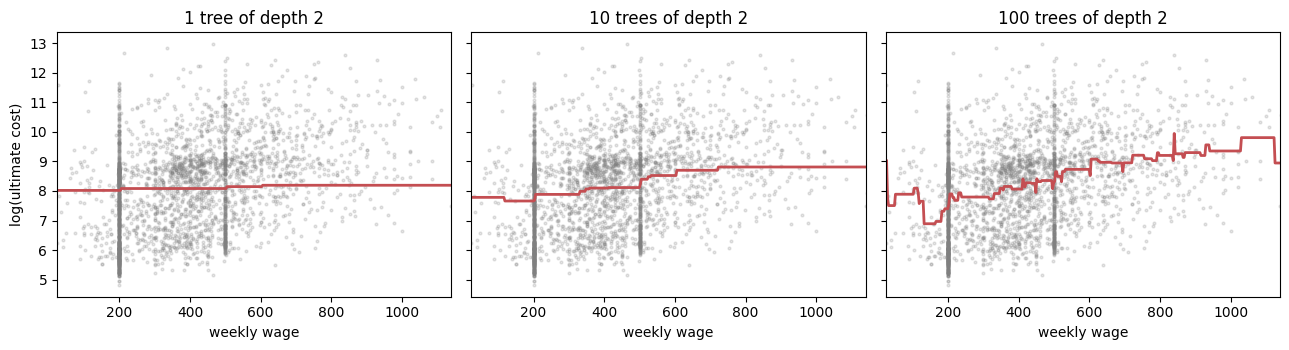

In [24]:
from sklearn.ensemble import GradientBoostingRegressor

wages = claims[["WeeklyWages"]]
low_wage, high_wage = wages["WeeklyWages"].quantile([0.01, 0.99])
grid = pd.DataFrame({"WeeklyWages": np.linspace(low_wage, high_wage, 400)})

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=True)
for ax, n_trees in zip(axes, [1, 10, 100]):
    booster = GradientBoostingRegressor(n_estimators=n_trees, max_depth=2, learning_rate=0.1, random_state=SEED)
    booster.fit(wages, log_cost)
    ax.scatter(wages["WeeklyWages"], log_cost, s=4, alpha=0.2, color="grey")
    ax.plot(grid["WeeklyWages"], booster.predict(grid), color="#C44E52", linewidth=2)
    ax.set_xlim(low_wage, high_wage)
    ax.set_title(f"{n_trees} tree{'s' if n_trees > 1 else ''} of depth 2")
    ax.set_xlabel("weekly wage")
axes[0].set_ylabel("log(ultimate cost)")
fig.tight_layout()
plt.show()

### 6.3 Training and test data

A flexible model can learn the training claims by heart — including their noise — and then predict new claims worse than a simpler model would. That is **overfitting**, and the only honest protection is to judge a model on claims it has never seen.

So, as in the article, we set 20% of the claims aside as a **test set** before any model is fitted, and nothing is fitted or chosen on it. Section 7 reports its comparisons on it; exercise (b) repeats the decisive ones with cross-validation on the training claims. The split is **stratified by cost decile**: the claims are sorted into ten equally large groups by log cost, and each group is split 80/20 on its own. Every part of the cost distribution — the smallest claims as well as the largest — is then represented in the test set in its true proportion, which a purely random draw of 600 claims would not guarantee.

In [25]:
from sklearn.model_selection import train_test_split

y = log_cost  # the target: log of the ultimate cost
deciles = pd.qcut(y, q=10, labels=False, duplicates="drop")
train_idx, test_idx = train_test_split(np.arange(len(claims)), test_size=0.20, stratify=deciles, random_state=SEED)

split = pd.DataFrame({
    "claims in training": deciles.iloc[train_idx].value_counts().sort_index(),
    "claims in test": deciles.iloc[test_idx].value_counts().sort_index(),
})
split.index = [f"decile {d + 1}" for d in split.index]
split.loc["total"] = split.sum()
display(split.T)
print(f"Training set: {len(train_idx):,} claims, mean log cost {y.iloc[train_idx].mean():.4f}")
print(f"Test set    : {len(test_idx):,} claims, mean log cost {y.iloc[test_idx].mean():.4f}")

,decile 1,decile 2,decile 3,decile 4,decile 5,decile 6,decile 7,decile 8,decile 9,decile 10,total
claims in training,240,240,240,240,240,240,240,240,240,240,2400
claims in test,60,60,60,60,60,60,60,60,60,60,600


Training set: 2,400 claims, mean log cost 8.0873
Test set    : 600 claims, mean log cost 8.0874


Every decile contributes 240 claims to the training set and 60 to the test set, and the two sets have the same mean log cost to three decimals (8.0873 and 8.0874). It is the article's split, claim for claim: the same data, the same deciles, the same seed.

### 6.4 Cross-validation, briefly

A single test set gives a single number, with no idea of how much it would move on another 600 claims. **Cross-validation** splits the training set into four **folds** of 600 claims and fits the model four times, each time on three folds (1,800 claims) and checking it on the fourth:

| round | fold 1 | fold 2 | fold 3 | fold 4 |
| --- | --- | --- | --- | --- |
| 1 | **check** | fit | fit | fit |
| 2 | fit | **check** | fit | fit |
| 3 | fit | fit | **check** | fit |
| 4 | fit | fit | fit | **check** |

That gives four scores instead of one — a mean and a spread — and it can compare settings, such as the number of trees, without ever touching the test set. The article's research notebook chose its model settings this way; section 7 uses those settings as they are, and exercise (b) shows how they are found and how to compare two models fairly with the four scores.

### 6.5 Measuring the error

Write $y_i$ for the log cost of claim $i$, $\hat y_i$ for its prediction and $\bar y$ for the mean of the $y_i$ over the $n$ claims scored.

- **RMSE**, the root mean squared error: $\sqrt{\tfrac{1}{n}\sum_i (y_i - \hat y_i)^2}$. The typical size of an error, with large errors weighted more. Lower is better.
- **MAE**, the mean absolute error: $\tfrac{1}{n}\sum_i |y_i - \hat y_i|$. The average size of an error, all errors weighted alike. Lower is better.
- **R²**, the coefficient of determination: $1 - \sum_i (y_i - \hat y_i)^2 \,/\, \sum_i (y_i - \bar y)^2$. The share of the variation in log cost that the model explains: 0 means no better than predicting the mean for every claim, 1 means perfect. Higher is better.

Three claims make the formulas concrete. The predictions are round numbers chosen for the example, not the output of a model:

In [26]:
example = claims_file.set_index("ClaimNumber").loc[["WC4878187", "WC6807703", "WC4490127"], ["UltimateIncurredClaimCost"]]
example["log cost y"] = np.log(example["UltimateIncurredClaimCost"])
example["prediction"] = [7.5, 8.5, 9.5]
example["error y - prediction"] = example["log cost y"] - example["prediction"]
example["actual / predicted cost"] = np.exp(example["error y - prediction"])
display(example.round(3))

errors = example["error y - prediction"]
rmse = np.sqrt((errors ** 2).mean())
mae = errors.abs().mean()
r2 = 1 - (errors ** 2).sum() / ((example["log cost y"] - example["log cost y"].mean()) ** 2).sum()
print(f"RMSE = sqrt(({' + '.join(f'({e:.3f})^2' for e in errors)}) / 3) = {rmse:.3f}")
print(f"MAE  = ({' + '.join(f'|{e:.3f}|' for e in errors)}) / 3 = {mae:.3f}")
print(f"R2   = 1 - {(errors ** 2).sum():.3f} / {((example['log cost y'] - example['log cost y'].mean()) ** 2).sum():.3f} = {r2:.3f}")
print(f"exp(MAE) = {np.exp(mae):.2f}: a typical prediction here is off by a factor of about {np.exp(mae):.1f}, up or down")

,UltimateIncurredClaimCost,log cost y,prediction,error y - prediction,actual / predicted cost
ClaimNumber,,,,,
WC4878187,1119.199,7.020,7.5,-0.480,0.619
WC6807703,7087.866,8.866,8.5,0.366,1.442
WC4490127,27183.693,10.210,9.5,0.710,2.035


RMSE = sqrt(((-0.480)^2 + (0.366)^2 + (0.710)^2) / 3) = 0.538
MAE  = (|-0.480| + |0.366| + |0.710|) / 3 = 0.519
R2   = 1 - 0.869 / 5.130 = 0.831
exp(MAE) = 1.68: a typical prediction here is off by a factor of about 1.7, up or down


The first claim was predicted 0.48 too high on the log scale: it cost 0.619 times its prediction. The third was predicted 0.71 too low: it cost 2.035 times its prediction. The RMSE (0.538) is a little larger than the MAE (0.519) because squaring gives the largest error, 0.71, more weight. The R² of 0.831 says that these three predictions explain most of the spread between three different claims — easy with three claims, much harder with 600.

**What an error on the log scale means in money.** An error of $d$ on the log scale means that the actual cost is $e^{d}$ times the predicted one. So $\exp(\text{MAE})$ is a **typical miss factor**: an MAE of 0.8 means that a typical prediction is off by a factor of $e^{0.8} \approx 2.2$ — twice too high or half too low, give or take. Section 7 reports this factor for both models. The RMSE, around 1.1 in this case study, weights the large misses more: $e^{1.1} \approx 3$.

### 6.6 Why the log of the cost?

The histograms of section 2.5 give the reason. The ultimate cost is right-skewed (skewness 6.99; the mean, 10,685, is three times the median, 3,573): a few large claims would dominate any squared error, and a model fitted to the raw cost would spend its effort on them. On the log scale the distribution is close to symmetric (skewness 0.21), and an error means a *ratio* — a factor of two is the same error on a claim of 1,000 as on a claim of 100,000. The price is that the model predicts log cost, so a prediction must be transformed back, and averages on the log scale are geometric means in money.

---

## 7 Predicting the claim cost

### Why it matters for actuaries

This is the question the whole case study asks: does the text help? Two models answer it, each with its own features and with the settings the article's research notebook tuned for it by cross-validation: 50 trees for the baseline, 200 for the enhanced model, both of depth 3. The **baseline** sees the 18 tabular features of section 2.6. The **enhanced** model sees the same 18 plus the three fields GPT-6 Luna extracted. The difference between them on the test set is the value of the claim descriptions, each model at its best settings — as far as one split of 3,000 claims can show it.

### 7.1 The two feature sets

The two classes become indicator (0/1) columns, one per class, with one class of each left out because it is implied by the others: EYES for the body part and CHEMICAL_BURN for the cause, as in the article. The count enters as a number. The class lists are fixed in advance by the schema, so the columns are the same whatever the model happens to answer — a class nobody chose still gets its column.

In [27]:
BODY_LEVELS = sorted(BODY_CLASSES)    # alphabetical, as in the article: EYES comes first and is left out
CAUSE_LEVELS = sorted(CAUSE_CLASSES)  # CHEMICAL_BURN comes first and is left out
COUNT = "number_of_body_parts_injured"
BODY_COLUMNS = [f"body_{level}" for level in BODY_LEVELS[1:]]
CAUSE_COLUMNS = [f"cause_{level}" for level in CAUSE_LEVELS[1:]]
# The article's column order: the count follows the numeric fields, the indicators come last.
ENHANCED_FEATURES = NUMERIC_FEATURES + [COUNT] + BINARY_FEATURES + DATE_FEATURES + BODY_COLUMNS + CAUSE_COLUMNS


def indicators(values: pd.Series, levels: list, prefix: str) -> pd.DataFrame:
    """One 0/1 column per level except the first, from levels fixed in advance."""
    if values.isna().any() or not set(values).issubset(levels):
        raise ValueError(f"{prefix}: missing values, or values outside {levels}")
    table = pd.get_dummies(pd.Categorical(values, categories=levels), prefix=prefix, drop_first=True, dtype=int)
    table.index = values.index
    return table


def check_no_forbidden_columns(matrix: pd.DataFrame) -> None:
    # A model matrix may hold features only: no target, no identifier, no raw text, no initial cost estimate.
    forbidden = [c for c in matrix.columns if re.search("initialincurred", c, flags=re.IGNORECASE)
                 or c in {"UltimateIncurredClaimCost", "ClaimNumber", "ClaimDescription", "DateTimeOfAccident", "DateReported"}]
    if forbidden:
        raise ValueError(f"forbidden columns in a model matrix: {forbidden}")


X_enhanced = pd.concat([X_baseline, luna[[COUNT]],
                        indicators(luna["body_part_category"], BODY_LEVELS, "body"),
                        indicators(luna["cause_of_injury_category"], CAUSE_LEVELS, "cause")], axis=1)[ENHANCED_FEATURES]
FEATURE_SETS = {"baseline": X_baseline, "enhanced": X_enhanced}
for name, matrix in FEATURE_SETS.items():
    check_no_forbidden_columns(matrix)
    print(f"[PASS] {name:<9}: {matrix.shape[1]} features, {len(matrix):,} claims, no forbidden column")
print(f"\nAdded by the extraction ({X_enhanced.shape[1] - X_baseline.shape[1]}): {COUNT},")
print("  " + ", ".join(BODY_COLUMNS) + ",")
print("  " + ", ".join(CAUSE_COLUMNS))

[PASS] baseline : 18 features, 3,000 claims, no forbidden column
[PASS] enhanced : 38 features, 3,000 claims, no forbidden column

Added by the extraction (20): number_of_body_parts_injured,
  body_HAND_FINGERS, body_HEAD_FACE, body_LOWER_EXTREMITY, body_NECK, body_OTHER, body_TORSO, body_UPPER_EXTREMITY,
  cause_COMPRESSION, cause_CONTACT, cause_DRIVING, cause_ERGONOMIC, cause_FALL_SLIP_TRIP, cause_IMPACT, cause_LACERATION, cause_LIFTING_CARRYING, cause_MEDICAL, cause_OTHER, cause_STRAIN_SPRAIN, cause_WALKING


### 7.2 The model settings

The settings are those the article's research notebook chose by cross-validation on the training set — a grid of 50, 100 or 200 trees of depth 3, 5 or 7 — for its baseline, its enhanced model and each variant of its ablation study. We take them as they are; exercise (b) shows how they are found, and re-tunes them for GPT-6 Luna's features. The learning rate is 0.1 and the random seed 42 throughout.

In [28]:
SETTINGS = {  # (number of trees, depth), from the article's research notebook
    "baseline": (50, 3),
    "enhanced": (200, 3),
    "+ body part": (200, 3),
    "+ cause": (100, 3),
    "+ count": (50, 3),
}


def fit_booster(X: pd.DataFrame, settings: tuple[int, int], rows=None) -> GradientBoostingRegressor:
    n_trees, depth = settings
    rows = train_idx if rows is None else rows
    booster = GradientBoostingRegressor(n_estimators=n_trees, max_depth=depth, learning_rate=0.1, random_state=SEED)
    return booster.fit(X.iloc[rows], y.iloc[rows])


def scores(y_true, y_pred) -> dict:
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    return {"RMSE": float(np.sqrt(np.mean((y_true - y_pred) ** 2))),
            "MAE": float(np.mean(np.abs(y_true - y_pred))),
            "R2": float(1 - np.sum((y_true - y_pred) ** 2) / np.sum((y_true - y_true.mean()) ** 2))}


pd.DataFrame(SETTINGS, index=["trees", "depth"]).T

,trees,depth
baseline,50,3
enhanced,200,3
+ body part,200,3
+ cause,100,3
+ count,50,3


### 7.3 The result on the test set

Both models are fitted on the 2,400 training claims and scored once on the 600 test claims. The improvement is the reduction of RMSE and MAE, and the increase of R², relative to the baseline; the last row turns the MAE into the miss factor of section 6.5.

In [29]:
boosters, test_predictions, test_scores = {}, {}, {}
for name, matrix in FEATURE_SETS.items():
    boosters[name] = fit_booster(matrix, SETTINGS[name])
    test_predictions[name] = boosters[name].predict(matrix.iloc[test_idx])
    test_scores[name] = scores(y.iloc[test_idx], test_predictions[name])

rows = {}
for metric in ["RMSE", "MAE", "R2"]:
    base, enhanced = test_scores["baseline"][metric], test_scores["enhanced"][metric]
    change = (enhanced - base) / abs(base) if metric == "R2" else (base - enhanced) / base
    rows[metric] = {"baseline": f"{base:.4f}", "enhanced": f"{enhanced:.4f}", "improvement": f"{change:.1%}"}
rows["miss factor exp(MAE)"] = {"baseline": f"{np.exp(test_scores['baseline']['MAE']):.2f}",
                                "enhanced": f"{np.exp(test_scores['enhanced']['MAE']):.2f}", "improvement": ""}
pd.DataFrame(rows).T

,baseline,enhanced,improvement
RMSE,1.3425,1.1216,16.5%
MAE,1.0729,0.8452,21.2%
R2,0.2274,0.4607,102.6%
miss factor exp(MAE),2.92,2.33,


For reference, the article's own test results on the same split, with its extraction:

| | baseline | enhanced |
| --- | --- | --- |
| RMSE | 1.345 | 1.101 |
| MAE | 1.078 | 0.834 |
| R² | 0.224 | 0.481 |

**The descriptions help, and by a wide margin.** On the 600 test claims the enhanced model lowers the RMSE from 1.3425 to 1.1216 (16.5%) and the MAE from 1.0729 to 0.8452 (21.2%), and it doubles the share of the variation explained, from R² = 0.2274 to 0.4607. In money terms the typical miss factor falls from 2.92 to 2.33: a typical baseline prediction is off by a factor of almost three, a typical enhanced one by a little over two. That is still a wide error band — no feature built from a description can separate the eleven claims of section 2.3 — but it is a clear step.

The picture is the article's: the same split, the same model settings and an improvement of similar size. The two gaps to the article's numbers have different causes. The baseline, 1.3425 against 1.345, differs only because of the reporting delay of section 2.6: with the research notebook's delay it gives 1.3453, the article's figure. The enhanced model, 1.1216 against 1.101, differs because of the extraction: GPT-6 Luna's fields lower the RMSE by 16.5%, the article's by about 18%. Fixing the classes in the schema did not buy a better model than the article's; on this split it is slightly weaker, by about the spread of one cross-validation fold. What it bought is a shorter pipeline, with nothing to map afterwards, whose every answer is a valid class by construction.

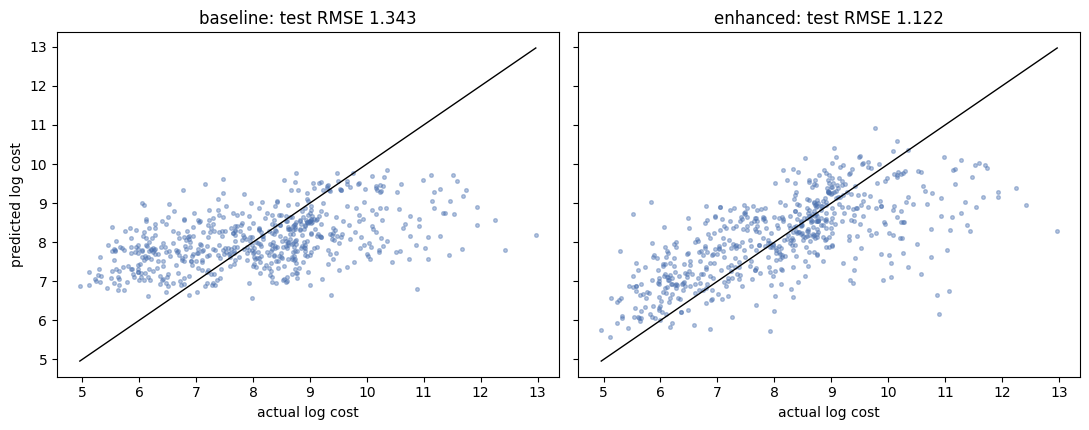

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4), sharex=True, sharey=True)
y_test = y.iloc[test_idx]
for ax, name in zip(axes, FEATURE_SETS):
    ax.scatter(y_test, test_predictions[name], s=7, alpha=0.4, color="#4C72B0")
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="black", linewidth=1)
    ax.set_title(f"{name}: test RMSE {test_scores[name]['RMSE']:.3f}")
    ax.set_xlabel("actual log cost")
axes[0].set_ylabel("predicted log cost")
fig.tight_layout()
plt.show()

The black line marks a perfect prediction. The baseline's predictions are squeezed into a narrow band around the average: knowing nothing about what happened, it predicts much the same cost for every claim. The enhanced model spreads its predictions out along the line. Both models still predict the most expensive claims far too low, as section 7.5 shows.

### 7.4 Which of the three fields does the work?

An **ablation** adds one group of new features at a time to the baseline: only the body-part indicators, only the cause indicators, only the count. Each variant uses the settings of the article's research notebook for that variant. All five are scored on the same 600 test claims.

A caveat before reading the table: this is one split. Differences of a few hundredths between variants can come from which 600 claims happened to land in the test set; exercise (b) shows how cross-validation puts an error bar on such comparisons.

In [31]:
VARIANT_COLUMNS = {
    "baseline": BASELINE_FEATURES,
    "+ body part": [c for c in ENHANCED_FEATURES if c not in CAUSE_COLUMNS + [COUNT]],
    "+ cause": [c for c in ENHANCED_FEATURES if c not in BODY_COLUMNS + [COUNT]],
    "+ count": [c for c in ENHANCED_FEATURES if c not in BODY_COLUMNS + CAUSE_COLUMNS],
    "enhanced": ENHANCED_FEATURES,
}
ablation = {}
for name, columns in VARIANT_COLUMNS.items():
    booster = fit_booster(X_enhanced[columns], SETTINGS[name])
    ablation[name] = {"features": len(columns), "trees, depth": str(SETTINGS[name]),
                      **scores(y.iloc[test_idx], booster.predict(X_enhanced[columns].iloc[test_idx]))}
ablation = pd.DataFrame(ablation).T
ablation["RMSE vs baseline"] = (ablation["RMSE"].astype(float) - ablation.loc["baseline", "RMSE"]).map("{:+.4f}".format)
ablation[["RMSE", "MAE", "R2"]] = ablation[["RMSE", "MAE", "R2"]].astype(float).round(4)
ablation

,features,"trees, depth",RMSE,MAE,R2,RMSE vs baseline
baseline,18,"(50, 3)",1.3425,1.0729,0.2274,+0.0000
+ body part,25,"(200, 3)",1.1452,0.8730,0.4378,-0.1973
+ cause,30,"(100, 3)",1.1892,0.9055,0.3938,-0.1533
+ count,19,"(50, 3)",1.3415,1.0711,0.2286,-0.0011
enhanced,38,"(200, 3)",1.1216,0.8452,0.4607,-0.2209


The body part does most of the work: on its own it lowers the test RMSE by 0.1973, almost as much as all three fields together (0.2209). The cause alone is worth 0.1533, and the count almost nothing (0.0011). The body part and the cause overlap — a back injury is often a lifting or strain injury — so their gains do not add up, and together they give only a little more than the body part alone. The order is the one the article's ablation study found. The caveat stands: this is one split of 600 claims.

### 7.5 Small claims, large claims

A single RMSE over all claims can hide different errors for small and large claims. The test claims are grouped by their ultimate cost, in the article's four bands, and both models are scored within each band. The errors are still measured on the log scale.

In [32]:
bands = pd.cut(cost.iloc[test_idx], bins=[0, 1_000, 5_000, 20_000, np.inf],
               labels=["below 1,000", "1,000 to 5,000", "5,000 to 20,000", "above 20,000"])
rows = []
for band in bands.cat.categories:
    mask = (bands == band).to_numpy()
    base, enh = (scores(y_test[mask], test_predictions[name][mask]) for name in ["baseline", "enhanced"])
    rows.append({"band": band, "claims": int(mask.sum()),
                 "RMSE baseline": base["RMSE"], "RMSE enhanced": enh["RMSE"],
                 "MAE baseline": base["MAE"], "MAE enhanced": enh["MAE"],
                 "mean log cost": float(y_test[mask].mean()),
                 "mean prediction, enhanced": float(test_predictions["enhanced"][mask].mean())})
pd.DataFrame(rows).set_index("band").round(3)

,claims,RMSE baseline,RMSE enhanced,MAE baseline,MAE enhanced,mean log cost,"mean prediction, enhanced"
band,,,,,,,
"below 1,000",155,1.606,1.095,1.489,0.920,6.156,7.023
"1,000 to 5,000",194,0.740,0.801,0.586,0.637,7.770,8.032
"5,000 to 20,000",179,0.985,0.774,0.805,0.592,9.034,8.824
"above 20,000",72,2.362,2.164,2.153,1.875,10.745,8.889


The enhanced model improves three of the four bands, the smallest claims most: below 1,000 the RMSE falls from 1.606 to 1.095, between 5,000 and 20,000 from 0.985 to 0.774, and above 20,000 from 2.362 to 2.164. Between 1,000 and 5,000 — the middle of the distribution, where the baseline's near-average predictions happen to be about right — the enhanced model is slightly worse (0.801 against 0.740), as in the article. Read the bands with care: they are cut on the actual cost, which no model knows in advance, and the top band holds only 72 claims.

The last two columns show the limit of both models. For the 72 test claims above 20,000 the mean log cost is 10.745, but the enhanced model predicts 8.889 on average: on the log scale that is 1.86 too low, a factor of about six. For the 155 claims below 1,000 it predicts too much (7.023 against 6.156). A model fitted to squared error pulls every prediction towards the average, and the largest claims — the ones that matter most for reserves — remain the hardest to predict from a line of text.

### 7.6 Which features the model relies on

Gradient boosting reports how much each feature reduced the squared error over all its trees, as a share of the total: the **feature importance**. It says which features the model used, not whether they cause anything, and it spreads credit between correlated features somewhat arbitrarily. Grouped, it shows how much of the enhanced model rests on the extraction.

,importance,group
WeeklyWages,0.232,tabular (18 features)
body_TORSO,0.132,body part (7)
Reported_Year,0.085,tabular (18 features)
body_HAND_FINGERS,0.067,body part (7)
cause_IMPACT,0.061,cause (12)
Age,0.058,tabular (18 features)
cause_CONTACT,0.042,cause (12)
Rep_Acc_Diff,0.034,tabular (18 features)
Accident_Year,0.032,tabular (18 features)
cause_LACERATION,0.026,cause (12)


Importance by group, enhanced model:
tabular (18 features)    0.562
body part (7)            0.247
cause (12)               0.173
count (1)                0.018

Top five of the baseline model: WeeklyWages 0.473, Age 0.123, Reported_Year 0.115, Rep_Acc_Diff 0.048, Accident_Year 0.047


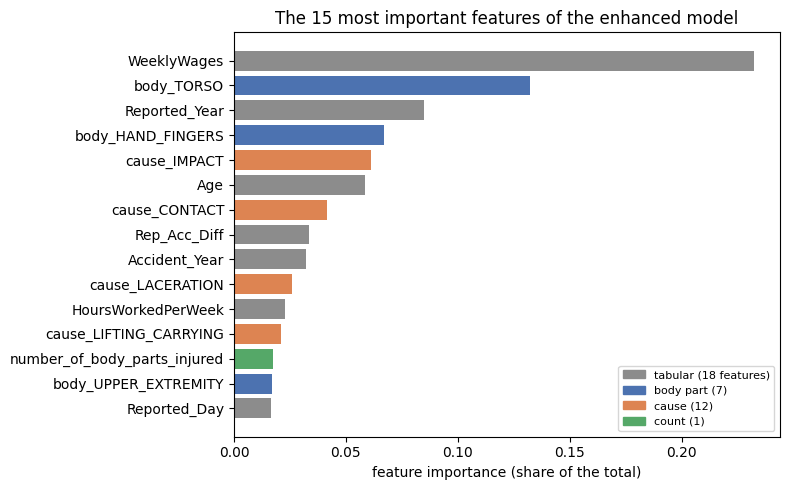

In [33]:
importance = pd.Series(boosters["enhanced"].feature_importances_, index=ENHANCED_FEATURES).sort_values(ascending=False)
GROUPS = {"tabular (18 features)": BASELINE_FEATURES, "body part (7)": BODY_COLUMNS, "cause (12)": CAUSE_COLUMNS, "count (1)": [COUNT]}
group_of = {column: group for group, columns in GROUPS.items() for column in columns}

display(pd.DataFrame({"importance": importance.head(15).round(3), "group": importance.head(15).index.map(group_of)}))
group_totals = pd.Series({group: importance[columns].sum() for group, columns in GROUPS.items()}).round(3)
print("Importance by group, enhanced model:")
print(group_totals.to_string())
baseline_importance = pd.Series(boosters["baseline"].feature_importances_, index=BASELINE_FEATURES).sort_values(ascending=False)
print("\nTop five of the baseline model:", ", ".join(f"{c} {v:.3f}" for c, v in baseline_importance.head(5).items()))

from matplotlib.patches import Patch

colours = {"tabular (18 features)": "#8C8C8C", "body part (7)": "#4C72B0", "cause (12)": "#DD8452", "count (1)": "#55A868"}
top = importance.head(15)[::-1]
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top.index, top.values, color=[colours[group_of[c]] for c in top.index])
ax.set_xlabel("feature importance (share of the total)")
ax.set_title("The 15 most important features of the enhanced model")
ax.legend(handles=[Patch(color=colour, label=group) for group, colour in colours.items()], loc="lower right", fontsize=8)
fig.tight_layout()
plt.show()

The weekly wage is still the most important single feature (0.232), but the torso indicator comes second (0.132), and three more extracted classes — hand and fingers, impact and contact — are in the top seven. Taken together the extracted features carry 44% of the enhanced model's importance: 0.247 for the body part, 0.173 for the cause and 0.018 for the count, against 0.562 for the 18 tabular features. In the baseline model the weekly wage alone had 0.473. As in the article, the weekly wage and the torso and hand classes lead the ranking; among the causes, impact comes first.

---

## 8 What to take away

- **A line of free text is a data source.** Three fields read from the claim descriptions cut the test RMSE on the log cost by 16.5% and the typical miss factor from 2.92 to 2.33, and the body part did most of the work.
- **Put the classes in the schema.** With `Literal` fields the provider returns one of the permitted class names and nothing else, so there are no mapping rules to maintain and nothing left to map. The class definitions and tie-break rules in the instructions are where the actuarial judgement goes: write them down and keep them in one place.
- **Check without labels.** Read answers next to their notes, look at the class distributions, and ask twice: 99 of 100 answers were identical on a second run, and 487 of 500 matched the recording. The answers that change are the borderline notes.
- **Engineer the run.** One call per distinct description (580 calls saved), requests in parallel, retries with growing pauses, a cache that survives an interruption, failures kept apart from answers, and a ledger. With OpenAI's prompt cache the whole extraction cost USD 0.082 (USD 0.365 without).
- **Record once, and model on the recording.** GPT-6 Luna is an alias without a dated snapshot, and it is not fully deterministic even at temperature 0. A recorded extraction with its model, settings, date and fingerprint makes the model reproducible and auditable.
- **The text does not explain everything.** Identical descriptions cost anything from 1,119 to 46,541, and the largest claims are still predicted far too low. One test split is also only one number: exercise (b) puts an error bar on it.

---

## 9 Exercises

> **Two exercises for those who finish early.** Both follow the same pattern: a cell marked TODO, where `student_... = None` leaves the reference solution in charge, so that everything below it runs and you can read its results first. Write your own code where the TODO shows you, below the line `student_... = None`, and run the cells again: once your code defines the name, it replaces the `None`. Exercise (a) makes a few live calls; exercise (b) needs no key.

### 9.1 Exercise (a): design your own feature

#### Why it matters for actuaries

The three fields of the article are one choice among many. A claims handler reading "SPRAINED RIGHT ANKLE FRACTURE RIGHT ELBOW" notices the fracture at once — and neither the body part nor the cause records it. Any question you can ask of a description can become a feature, but each one costs an extraction, and it should earn that cost in the model.

**The worked example: the nature of the injury.** The cause says what happened; the *nature* of the injury says what the injury is. A fracture and a bruise can have the same cause and the same body part and cost different amounts. The new field has ten classes, fixed in advance like the others:

In [34]:
NATURE_CLASSES = {
    "FRACTURE": "a broken, fractured or chipped bone",
    "DISLOCATION": "a dislocated joint",
    "SPRAIN_STRAIN": "a sprain or strain of a muscle, tendon or ligament, including a twisted joint, a pulled or "
                     "torn muscle or ligament, and whiplash",
    "LACERATION_PUNCTURE": "an open wound: a cut, laceration, puncture, stab wound, abrasion or graze",
    "CONTUSION_BRUISE": "a bruise, contusion or bump, including a crush injury without a fracture",
    "BURN": "a burn or scald from heat, flame, hot liquid, steam, chemicals or electricity, including a welding flash",
    "FOREIGN_BODY": "a foreign body or splinter in the eye or the skin",
    "AMPUTATION": "the loss of a finger, fingertip, toe or other body part",
    "OTHER": "an injury that fits none of the classes above, such as a hernia, an infection, tendonitis, bursitis, "
             "an irritation or an electric shock",
    "NOT_STATED": "the description names no injury, only a body part, a mechanism or a symptom such as pain",
}


class InjuryNature(BaseModel):
    nature_of_injury: Literal[tuple(NATURE_CLASSES)] = Field(
        description="Class of the nature of the primary injury: what the injury is, not what caused it")


NATURE_INSTRUCTIONS = f"""You classify workers' compensation claim descriptions. A description is a short note in \
capitals: articles and verbs are often left out, words can be repeated, misspelt or cut off at the end. Read a \
misspelt or cut-off word as the word that is clearly meant. Use only what the description says, and never guess \
beyond it.

Return one field, nature_of_injury: the class of the NATURE of the primary injury - what the injury is, not what \
caused it.
{class_lines(NATURE_CLASSES)}
Rules:
- The nature is the injury itself. STRUCK BY BOX BRUISED ARM is CONTUSION_BRUISE; CAUGHT FINGER IN DOOR FRACTURED \
FINGER is FRACTURE.
- If several injuries are named, take the injury to the body part the description names first as injured.
- Pain, soreness or a bare INJURED or INJURY with no injury named is NOT_STATED.
"""

NATURE_FIELD = {"name": "nature_of_injury", "schema": InjuryNature, "instructions": NATURE_INSTRUCTIONS,
                "recording": "luna_nature_of_injury_3000"}

with pd.option_context("display.max_colwidth", None):
    display(pd.DataFrame({"nature class": list(NATURE_CLASSES), "what it covers": list(NATURE_CLASSES.values())})
            .set_index("nature class"))

,what it covers
nature class,
FRACTURE,"a broken, fractured or chipped bone"
DISLOCATION,a dislocated joint
SPRAIN_STRAIN,"a sprain or strain of a muscle, tendon or ligament, including a twisted joint, a pulled or torn muscle or ligament, and whiplash"
LACERATION_PUNCTURE,"an open wound: a cut, laceration, puncture, stab wound, abrasion or graze"
CONTUSION_BRUISE,"a bruise, contusion or bump, including a crush injury without a fracture"
BURN,"a burn or scald from heat, flame, hot liquid, steam, chemicals or electricity, including a welding flash"
FOREIGN_BODY,a foreign body or splinter in the eye or the skin
AMPUTATION,"the loss of a finger, fingertip, toe or other body part"
OTHER,"an injury that fits none of the classes above, such as a hernia, an infection, tendonitis, bursitis, an irritation or an electric shock"


**Your turn.** The cell below is where your own field goes: a question with a fixed set of answers — was a third party involved, how severe does the injury sound, is the claim likely to involve time off work? Write a Pydantic class with one `Literal` field, instructions that define every value, and put them in the dictionary. While `student_field` is `None`, the cells below run the worked example.

In [35]:
# ----------------------------------------------------------------------------------------------------------
# TODO - your own field: a dictionary like NATURE_FIELD above. Write it below the next line, or uncomment and
# complete the example; once it defines student_field, it replaces the None.
# ----------------------------------------------------------------------------------------------------------
student_field = None
#
# class ThirdParty(BaseModel):
#     third_party_involved: Literal["YES", "NO", "NOT_STATED"] = Field(
#         description="Did another person, an animal or another vehicle cause the injury?")
#
# student_field = {
#     "name": "third_party_involved",
#     "schema": ThirdParty,
#     "instructions": "You classify workers' compensation claim descriptions ... YES if ..., NO if ..., "
#                     "NOT_STATED if ...",
# }
#
# Keep to one Literal field with a handful of values: each value becomes one 0/1 column in the model.
# ----------------------------------------------------------------------------------------------------------

field = student_field or NATURE_FIELD
if student_field is None:
    print("[using reference solution — complete the TODO above]")
FIELD_NAME = field["name"]
FIELD_LEVELS = list(get_args(field["schema"].model_fields[FIELD_NAME].annotation))
FIELD_FINGERPRINT = extraction_fingerprint(field["schema"], field["instructions"])
print(f"Field: {FIELD_NAME}, {len(FIELD_LEVELS)} values: {', '.join(FIELD_LEVELS)}")
print(f"Fingerprint: {FIELD_FINGERPRINT[:12]}")

[using reference solution — complete the TODO above]
Field: nature_of_injury, 10 values: FRACTURE, DISLOCATION, SPRAIN_STRAIN, LACERATION_PUNCTURE, CONTUSION_BRUISE, BURN, FOREIGN_BODY, AMPUTATION, OTHER, NOT_STATED
Fingerprint: 353f3dcc303d


**Step 1: try it on 100 claims first.** The same 100 descriptions as the stability check of section 4.4, sent live. This costs less than one cent (USD 0.0066 in the saved run: these shorter requests get no prompt-cache discount), and it is where a badly defined value shows up — one class that takes everything, or one that is never used. Read the examples as well as the counts.

In [36]:
def recorded_field(fld: dict) -> tuple[pd.DataFrame | None, dict | None]:
    """The recorded extraction of a field, if it has one: (table, note of how it was made)."""
    if not fld.get("recording"):
        return None, None
    table_path, meta_path = data_file(f"{fld['recording']}.csv"), data_file(f"{fld['recording']}.json")
    if table_path is None or meta_path is None:
        return None, None
    return pd.read_csv(table_path), json.loads(meta_path.read_text(encoding="utf-8"))


field_table, field_meta = recorded_field(field)
if LIVE:
    try_records, try_summary = extract_many(stability_texts, schema=field["schema"], instructions=field["instructions"],
                                            purpose=f"exercise (a): {FIELD_NAME}, 100 claims")
    report_run(try_summary, f"{FIELD_NAME} on 100 claims")
    try_values = pd.Series([(try_records[t]["answer"] or {}).get(FIELD_NAME) for t in stability_texts])
elif field_table is not None:
    print("[ATTENTION] No key: showing the recorded answers for these 100 descriptions instead of live ones.")
    by_text = field_table.merge(claims_file[["ClaimNumber", "ClaimDescription"]], left_on="claim_number",
                                right_on="ClaimNumber").drop_duplicates("ClaimDescription").set_index("ClaimDescription")
    try_values = pd.Series([by_text[FIELD_NAME].get(t) for t in stability_texts])
else:
    try_values = None
    print("[ATTENTION] No key and no recording for this field: this step needs a key.")

if try_values is not None:
    counts = try_values.value_counts().reindex(FIELD_LEVELS, fill_value=0)
    print(f"\n{FIELD_NAME} on 100 descriptions:", ", ".join(f"{level} {n}" for level, n in counts.items()))
    with pd.option_context("display.max_colwidth", None):
        display(pd.DataFrame({"description": stability_texts[:12], FIELD_NAME: try_values[:12]}))

nature_of_injury on 100 claims: 100 distinct descriptions; 100 sent now, 0 read from the local cache.
  Tokens : 55,615 in (0 cached), 2,065 out
  Cost   : USD 0.0066 (USD 0.0066 with no caching)
  Time   : 9 seconds with up to 16 requests in parallel; 0 retries
[PASS] All 100 descriptions have an answer.

nature_of_injury on 100 descriptions: FRACTURE 3, DISLOCATION 0, SPRAIN_STRAIN 32, LACERATION_PUNCTURE 29, CONTUSION_BRUISE 9, BURN 1, FOREIGN_BODY 5, AMPUTATION 0, OTHER 6, NOT_STATED 15


,description,nature_of_injury
0,REPETITIVE LIFTING TENNIS ELBOW RIGHT ELBOW,OTHER
1,STRUCK KNIFE LACERATION LEFT WRIST TENDON SYNOVITIS,LACERATION_PUNCTURE
2,STRUCK OBJECT WITH HEAD CONCUSSION TO HEAD,OTHER
3,DRAFT SLAMMED DOOR ON LEFT SIDE OF ROAD RIGHT SHOULDER,NOT_STATED
4,INJURY TO LEFT ELBOW FRACTURED LEFT TALUS,FRACTURE
5,KNIFE CUT THUMB,LACERATION_PUNCTURE
6,STRUCK METAL SHEET LACERATED LEG LACERATED RIGHT INDEX FINGER,LACERATION_PUNCTURE
7,FELL FROM LADDER BRUISED BACK,CONTUSION_BRUISE
8,TRIPPED OVER CORD ACUTE STRAIN RIGHT KNEE,SPRAIN_STRAIN
9,WELDING AND CHIP IN EYE IRRITATION RIGHT EYE,OTHER


Every class except DISLOCATION and AMPUTATION appears among these 100 descriptions, which is no surprise for two rare injuries. SPRAIN_STRAIN (32) and LACERATION_PUNCTURE (29) lead, and NOT_STATED (15) takes the notes that name no injury, such as DRAFT SLAMMED DOOR ON LEFT SIDE OF ROAD RIGHT SHOULDER. Most examples read sensibly: a fractured talus is a FRACTURE, a knife cut a LACERATION_PUNCTURE, a bruised back after a fall a CONTUSION_BRUISE. One is debatable: WELDING AND CHIP IN EYE IRRITATION RIGHT EYE went to OTHER, as an irritation, although a chip in the eye is arguably a FOREIGN_BODY. A first try on 100 claims is where such a definition gets tightened, before 2,420 calls are paid for.

**Step 2: all claims.** For the worked example the extraction of all 3,000 claims was recorded once and is read from `data/luna_nature_of_injury_3000.csv`. For your own field there is no recording: set `RUN_FIELD_EXTRACTION = True` in the setup cell, and it is extracted live, one call per distinct description, with the same local cache as in section 5. The cell prints what that costs before it starts.

In [37]:
field_values = None
if field is NATURE_FIELD and not RUN_FIELD_EXTRACTION:
    if field_table is None:
        print("[ATTENTION] The recording of the worked example is missing - see the message above.")
    else:
        describe_recording(field_meta, f"Extraction of {FIELD_NAME} for all claims")
        if field_meta["fingerprint"] != FIELD_FINGERPRINT:
            print(f"[ATTENTION] The recording was made with other instructions (fingerprint {field_meta['fingerprint'][:12]}).")
        field_values = claims[["ClaimNumber"]].merge(field_table, left_on="ClaimNumber", right_on="claim_number",
                                                     how="left")[FIELD_NAME]
elif RUN_FIELD_EXTRACTION:
    require_client()
    if LIVE and try_summary["calls"]:
        estimate = try_summary["cost_usd_no_cache"] / try_summary["calls"] * claims["ClaimDescription"].nunique()
        print(f"About {claims['ClaimDescription'].nunique():,} calls, at most about USD {estimate:.2f}.")
    field_cache = LOCAL_DIR / "extractions" / f"{FIELD_NAME}_{FIELD_FINGERPRINT[:12]}.jsonl"
    field_cache.parent.mkdir(parents=True, exist_ok=True)
    field_records, field_summary = extract_many(claims["ClaimDescription"], schema=field["schema"],
                                                instructions=field["instructions"],
                                                purpose=f"exercise (a): {FIELD_NAME}, all claims", cache_path=field_cache)
    report_run(field_summary, f"{FIELD_NAME} for all claims")
    if field_summary["answers"] < field_summary["texts"]:
        print("[ATTENTION] Not every description has an answer yet - run this cell again to retry the failures.")
    else:
        field_values = pd.Series([field_records[t]["answer"][FIELD_NAME] for t in claims["ClaimDescription"]], name=FIELD_NAME)
        if field is NATURE_FIELD and N_CLAIMS == 3_000:  # re-record the worked example
            field_meta = run_meta(field_records, field_summary, list(claims["ClaimDescription"]), FIELD_FINGERPRINT)
            recording = pd.DataFrame({"claim_number": claims["ClaimNumber"], FIELD_NAME: field_values, "model": MODEL,
                                      "effort": EFFORT, "extraction_date": field_meta["extraction_date_utc"]})
            save_recording(recording, field_meta, NATURE_FIELD["recording"])
            describe_recording(field_meta, f"Extraction of {FIELD_NAME} for all claims")
else:
    print(f"[ATTENTION] '{FIELD_NAME}' has no recording. Set RUN_FIELD_EXTRACTION = True in the setup cell to extract it")
    print(f"            for all {len(claims):,} claims, then run the cells of this exercise again.")

if field_values is not None:
    field_values = field_values.reset_index(drop=True)
    valid = field_values.notna().all() and set(field_values).issubset(FIELD_LEVELS)
    print(("[PASS] " if valid else "[ATTENTION] ") + f"{FIELD_NAME}: {int(field_values.notna().sum()):,} of {len(claims):,} claims "
          f"have a value{'' if valid else ' - some are missing or outside the classes'}.")

Extraction of nature_of_injury for all claims, recorded on 2026-09-22 (UTC)
  Model and settings : gpt-6-luna, reasoning effort 'none', temperature 0
  Claims and calls   : 3,000 claims, 2,420 calls (one per distinct description), 0 failed, 0 retries
  Tokens             : 1,346,763 in (0 cached), 49,437 out
  Cost               : USD 0.1594 (USD 0.1594 with no caching)
  Time               : 195 seconds with 16 requests in parallel
[PASS] nature_of_injury: 3,000 of 3,000 claims have a value.


**Step 3: does it say anything about cost?** The distribution over all claims, and the median cost per value, as in section 5.4.

In [38]:
if field_values is not None:
    display(by_class(field_values, FIELD_LEVELS))
else:
    print("[ATTENTION] No values for this field yet - see step 2.")

,claims,share,median cost
nature_of_injury,,,
FRACTURE,110,3.7%,"5,805"
DISLOCATION,4,0.1%,"2,926"
SPRAIN_STRAIN,1060,35.3%,"6,469"
LACERATION_PUNCTURE,682,22.7%,904
CONTUSION_BRUISE,252,8.4%,"1,719"
BURN,81,2.7%,775
FOREIGN_BODY,175,5.8%,436
AMPUTATION,9,0.3%,"5,083"
OTHER,203,6.8%,"4,746"


The nature of the injury separates cheap from expensive claims at least as sharply as the cause does. Fractures (median 5,805) and sprains and strains (6,469) are expensive, and so are amputations (5,083), though there are only 9 of them; foreign bodies (436), burns (775) and open wounds (904) are cheap. NOT_STATED is large — 424 claims, 14.1% — because many notes name a body part and a mechanism but no injury, and its median of 5,346 lies well above the overall 3,573.

**Step 4: does it pay its way in the model?** The field's values become 0/1 columns, one per value except the first in alphabetical order, and join the 38 features of the enhanced model. The new model keeps the enhanced model's settings (200 trees of depth 3) and is scored on the same 600 test claims. Look at the result, but do not iterate on it: trying variants until the test score improves turns the test set into a training set. Exercise (b) is where a field is judged.

In [39]:
if field_values is not None:
    field_levels = sorted(FIELD_LEVELS)
    X_field = pd.concat([X_enhanced, indicators(field_values, field_levels, FIELD_NAME)], axis=1)
    FIELD_COLUMNS = [c for c in X_field.columns if c not in X_enhanced.columns]
    check_no_forbidden_columns(X_field)
    field_booster = fit_booster(X_field, SETTINGS["enhanced"])
    field_scores = scores(y_test, field_booster.predict(X_field.iloc[test_idx]))
    compare = pd.DataFrame({"enhanced (38 features)": test_scores["enhanced"],
                            f"enhanced + {FIELD_NAME} ({X_field.shape[1]} features)": field_scores}).round(4)
    compare["change"] = (compare.iloc[:, 1] - compare.iloc[:, 0]).map("{:+.4f}".format)
    display(compare)
    field_importance = pd.Series(field_booster.feature_importances_, index=X_field.columns)
    print(f"Importance of the {len(FIELD_COLUMNS)} new columns together: {field_importance[FIELD_COLUMNS].sum():.3f}")
    print("Largest:", ", ".join(f"{c} {v:.3f}" for c, v in field_importance[FIELD_COLUMNS].sort_values(ascending=False).head(3).items()))
else:
    X_field = None
    print("[ATTENTION] No values for this field yet - see step 2.")

,enhanced (38 features),enhanced + nature_of_injury (47 features),change
RMSE,1.1216,1.0441,-0.0775
MAE,0.8452,0.7774,-0.0678
R2,0.4607,0.5327,+0.0720


Importance of the 9 new columns together: 0.320
Largest: nature_of_injury_SPRAIN_STRAIN 0.123, nature_of_injury_FOREIGN_BODY 0.098, nature_of_injury_LACERATION_PUNCTURE 0.041


On the test split the nature of the injury pays its way: the RMSE falls by a further 0.0775, from 1.1216 to 1.0441, the MAE by 0.0678, and R² rises from 0.4607 to 0.5327. The nine new columns together carry 0.320 of the new model's importance, led by SPRAIN_STRAIN and FOREIGN_BODY. The field asks something the other three do not: what the injury is, not where it is or how it happened.

One split is not enough to call it. Exercise (b) repeats the comparison with cross-validation and a proper test.

### 9.2 Exercise (b): cross-validation and a fair comparison

#### Why it matters for actuaries

"The enhanced model has a lower test RMSE" is one number on one split of 600 claims. Before a new data source goes into a pricing or reserving process, you want to know two things: are the model settings right for the new features, and is the improvement larger than the noise of the split? Cross-validation answers the first, and — with the right test — the second. No key is needed from here on.

**Step 1: tuning the settings.** For each feature set, every combination of 50, 100 or 200 trees with depth 3, 5 or 7 is fitted four times — `StratifiedKFold` with 4 folds, shuffled with seed 42 and stratified by cost decile, on the training set only — and scored by its mean RMSE over the four validation folds. The test set is not touched. This is the tuning of the article's research notebook, now applied to GPT-6 Luna's features.

In [40]:
from scipy import stats
from sklearn.model_selection import StratifiedKFold

GRID = [(n_trees, depth) for n_trees in (50, 100, 200) for depth in (3, 5, 7)]
train_deciles = deciles.iloc[train_idx].to_numpy()
y_train = y.iloc[train_idx].reset_index(drop=True)


def cv_scores(X: pd.DataFrame, settings: tuple[int, int], seed: int) -> dict:
    """Stratified 4-fold cross-validation on the training set: RMSE, MAE and R2 of each fold."""
    X_train = X.iloc[train_idx].reset_index(drop=True)
    folds = StratifiedKFold(n_splits=4, shuffle=True, random_state=seed).split(X_train, train_deciles)
    per_fold = []
    for fit_rows, check_rows in folds:
        booster = GradientBoostingRegressor(n_estimators=settings[0], max_depth=settings[1], learning_rate=0.1,
                                            random_state=SEED).fit(X_train.iloc[fit_rows], y_train.iloc[fit_rows])
        per_fold.append(scores(y_train.iloc[check_rows], booster.predict(X_train.iloc[check_rows])))
    return {metric: np.array([fold[metric] for fold in per_fold]) for metric in ("RMSE", "MAE", "R2")}


CV_SETS = {"baseline": X_baseline, "enhanced": X_enhanced}
if X_field is not None:
    CV_SETS[f"enhanced + {FIELD_NAME}"] = X_field

started = time.time()
tuning, tuned = {}, {}
for name, matrix in CV_SETS.items():
    mean_rmse = {settings: cv_scores(matrix, settings, seed=SEED)["RMSE"].mean() for settings in GRID}
    tuning[name] = pd.Series(mean_rmse).unstack().rename_axis(index="trees", columns="depth")
    tuned[name] = min(mean_rmse, key=mean_rmse.get)
print(f"{len(CV_SETS) * len(GRID) * 4} models fitted in {time.time() - started:.0f} seconds.\n")
for name, table in tuning.items():
    print(f"{name}: mean validation RMSE; best {tuned[name]} (trees, depth)")
    display(table.round(4))
print("Settings chosen here:", {name: settings for name, settings in tuned.items()})
print("Settings of the research notebook, used in section 7: baseline (50, 3), enhanced (200, 3)")

108 models fitted in 60 seconds.

baseline: mean validation RMSE; best (50, 3) (trees, depth)


depth,3,5,7
trees,,,
50,1.3316,1.3466,1.3681
100,1.3343,1.3626,1.3935
200,1.3475,1.3924,1.4085


enhanced: mean validation RMSE; best (50, 5) (trees, depth)


depth,3,5,7
trees,,,
50,1.1267,1.1104,1.1248
100,1.1119,1.1131,1.1347
200,1.1114,1.1276,1.1456


enhanced + nature_of_injury: mean validation RMSE; best (100, 3) (trees, depth)


depth,3,5,7
trees,,,
50,1.0830,1.0807,1.1042
100,1.0692,1.0864,1.1135
200,1.0704,1.1023,1.1166


Settings chosen here: {'baseline': (50, 3), 'enhanced': (50, 5), 'enhanced + nature_of_injury': (100, 3)}
Settings of the research notebook, used in section 7: baseline (50, 3), enhanced (200, 3)


For the baseline, cross-validation picks the research notebook's setting again: 50 trees of depth 3. For the enhanced model it picks 50 trees of depth 5 instead of 200 trees of depth 3 — but the two differ by 0.001 in mean RMSE (1.1104 against 1.1114), far inside the noise; near its optimum the grid is flat. With the nature of the injury added, 100 trees of depth 3 come out best. For every feature set, 200 trees of depth 7 do worst: with 1,800 claims per fit, large deep models start to learn noise.

**Step 2: the scores with an error bar.** With the tuned settings fixed, every feature set is cross-validated again — on *new* folds (seed 43), so that the folds that picked the settings do not also judge them. All feature sets use the same four folds, which is what makes a paired comparison possible. The table gives the mean and the standard deviation over the four folds.

In [41]:
cv_results = {name: cv_scores(matrix, tuned[name], seed=EVAL_SEED) for name, matrix in CV_SETS.items()}
pd.DataFrame({
    name: {metric: f"{values.mean():.4f} ± {values.std():.4f}" for metric, values in result.items()}
    for name, result in cv_results.items()
}).T

,RMSE,MAE,R2
baseline,1.3229 ± 0.0204,1.0865 ± 0.0255,0.2434 ± 0.0198
enhanced,1.1231 ± 0.0167,0.8691 ± 0.0188,0.4546 ± 0.0174
enhanced + nature_of_injury,1.0765 ± 0.0342,0.8224 ± 0.0322,0.4987 ± 0.0296


With error bars, the gain from the extracted features is unmistakable: an RMSE of 1.3229 ± 0.0204 for the baseline against 1.1231 ± 0.0167 for the enhanced model, a gap about ten times the spread. The nature of the injury lowers the mean RMSE further, to 1.0765, but its spread is twice as large (± 0.0342), and its gap to the enhanced model, 0.047, is not much larger than that spread. As in the article, ± is the standard deviation of the four fold scores.

**Step 3: why the four fold scores are not independent.** It is tempting to compare two models with an ordinary paired t-test on their four fold scores. But any two of the four fitting sets share two of their three folds — two thirds of their claims — so the four scores are positively correlated: they move together, and their spread understates how much the result would change on genuinely new data. An ordinary t-test then finds significance too easily.

Nadeau and Bengio (2003) correct for this by inflating the variance. With $d_k$ the difference between the two models' scores on fold $k$, $\bar d$ its mean over the $K$ folds and $s_d^2$ its sample variance,

$$ t = \frac{\bar d}{\sqrt{\left(\dfrac{1}{K} + \dfrac{n_\text{check}}{n_\text{fit}}\right) s_d^2}}, \qquad \text{with } K - 1 \text{ degrees of freedom.} $$

For 4-fold cross-validation $n_\text{check}/n_\text{fit} = 600/1{,}800 = 1/3$, so the variance is multiplied by $1/4 + 1/3 = 7/12$ instead of the $1/4$ of the ordinary test: the standard error grows by a factor $\sqrt{7/3} \approx 1.53$. This is the test the article reports.

**Step 4: your turn.** Write the corrected test yourself. While `student_corrected_ttest` is `None`, the reference solution below it is used.

In [42]:
# ----------------------------------------------------------------------------------------------------------
# TODO - write the corrected paired t-test of Nadeau and Bengio (2003), using the formula above. Uncomment and
# complete the function below; once it is defined, it replaces the None.
# ----------------------------------------------------------------------------------------------------------
student_corrected_ttest = None
#
# def student_corrected_ttest(scores_a, scores_b, check_over_fit=1 / 3):
#     d = ...                     # the K differences scores_a - scores_b
#     t = ...                     # mean(d) / sqrt((1/K + check_over_fit) * sample variance of d)
#     p = ...                     # two-sided, t distribution with K - 1 degrees of freedom (scipy.stats.t.sf)
#     return t, p
# ----------------------------------------------------------------------------------------------------------


def reference_corrected_ttest(scores_a, scores_b, check_over_fit: float = 1 / 3) -> tuple[float, float]:
    """Reference solution: the corrected paired t-test of Nadeau and Bengio (2003)."""
    d = np.asarray(scores_a) - np.asarray(scores_b)
    k = len(d)
    t = d.mean() / np.sqrt((1 / k + check_over_fit) * d.var(ddof=1))
    return float(t), float(2 * stats.t.sf(abs(t), df=k - 1))


corrected_ttest = student_corrected_ttest or reference_corrected_ttest
if student_corrected_ttest is None:
    print("[using reference solution — complete the TODO above]")

[using reference solution — complete the TODO above]


**Step 5: the tests.** For each comparison, the mean improvement over the four folds, the corrected test and — for contrast — the ordinary paired t-test on the same four differences.

In [43]:
COMPARISONS = [("enhanced", "baseline")]
if X_field is not None:
    COMPARISONS.append((f"enhanced + {FIELD_NAME}", "enhanced"))

rows = []
for new, old in COMPARISONS:
    for metric in ("RMSE", "MAE"):
        t, p = corrected_ttest(cv_results[old][metric], cv_results[new][metric])
        naive = stats.ttest_rel(cv_results[old][metric], cv_results[new][metric])
        rows.append({"comparison": f"{new} vs {old}", "metric": metric,
                     "mean improvement": f"{(cv_results[old][metric] - cv_results[new][metric]).mean():.4f}",
                     "corrected t": f"{t:.2f}", "corrected p": f"{p:.2e}",
                     "ordinary t": f"{naive.statistic:.2f}", "ordinary p": f"{naive.pvalue:.2e}"})
pd.DataFrame(rows).set_index(["comparison", "metric"])

mean improvement corrected t corrected p ordinary t ordinary p
comparison                              metric                                                               
enhanced vs baseline                    RMSE             0.1998       16.64    4.72e-04      25.42   1.33e-04
                                        MAE              0.2174       13.74    8.34e-04      20.99   2.37e-04
enhanced + nature_of_injury vs enhanced RMSE             0.0466        2.81    6.73e-02       4.29   2.33e-02
                                        MAE              0.0466        3.55    3.81e-02       5.42   1.23e-02

The extracted features pass easily: a mean RMSE improvement of 0.1998, with a corrected t of 16.64 and p = 0.00047, of the same order as the article's t = 14.51. The nature of the injury is a closer call, and it shows why the correction matters. On RMSE its corrected test gives t = 2.81 and p = 0.067, not significant at 5%, while the ordinary t-test on the same four differences gives p = 0.023 and would have called it significant. On MAE the corrected test does reject (t = 3.55, p = 0.038). Four folds leave three degrees of freedom, so even a consistent gain has to be large to reach significance.

**Step 6: other folds.** Everything above rests on one way of cutting the training set into four folds. The cell repeats the evaluation for five different fold assignments (seeds 43 to 47), with the settings held fixed, and reports how much each comparison improves the RMSE in each, and how often it improves at all.

In [44]:
REPEAT_SEEDS = [43, 44, 45, 46, 47]
repeated = {seed: {name: cv_scores(matrix, tuned[name], seed=seed)["RMSE"].mean() for name, matrix in CV_SETS.items()}
            for seed in REPEAT_SEEDS}
repeated = pd.DataFrame(repeated).T.rename_axis("fold seed")
gains = pd.DataFrame({f"{new} vs {old}": repeated[old] - repeated[new] for new, old in COMPARISONS})
display(pd.concat([repeated.round(4), gains.add_prefix("RMSE gain: ").round(4)], axis=1))
for column in gains:
    print(f"{column}: RMSE gain {gains[column].mean():.4f} ± {gains[column].std():.4f}, "
          f"positive in {int((gains[column] > 0).sum())} of {len(gains)} fold assignments")

,baseline,enhanced,enhanced + nature_of_injury,RMSE gain: enhanced vs baseline,RMSE gain: enhanced + nature_of_injury vs enhanced
fold seed,,,,,
43,1.3229,1.1231,1.0765,0.1998,0.0466
44,1.3283,1.1188,1.0653,0.2095,0.0535
45,1.3222,1.1099,1.0640,0.2123,0.0459
46,1.3304,1.1090,1.0687,0.2215,0.0402
47,1.3243,1.1166,1.0737,0.2077,0.0429


enhanced vs baseline: RMSE gain 0.2101 ± 0.0078, positive in 5 of 5 fold assignments
enhanced + nature_of_injury vs enhanced: RMSE gain 0.0458 ± 0.0050, positive in 5 of 5 fold assignments


Across five fold assignments the picture holds: the extracted features lower the RMSE by 0.2101 ± 0.0078 and win in all five, and the nature of the injury lowers it by a further 0.0458 ± 0.0050 and wins in all five as well. Here ± is the sample standard deviation over the five fold assignments. The gain from the new field does not depend on how the folds are cut. That is not a significance test, though: repeating the cross-validation creates no new data, because all five assignments reuse the same 2,400 claims, and the corrected test on RMSE (p = 0.067) remains the verdict. Their agreement shows that the result does not hinge on one way of cutting the folds, not that it would hold on another portfolio.

**Things to try.**

1. Replace `student_field` with your own field, run exercise (a) with `RUN_FIELD_EXTRACTION = True`, and then exercise (b). Does your field pay its way under the corrected test?
2. Change one tie-break rule in the instructions of section 3.3 — the most serious injury instead of the first one named, say — re-extract with `RUN_FULL_EXTRACTION = True` and compare the models. How much do the rules matter?
3. In exercise (b), set `check_over_fit` to 0 in your t-test. That is the ordinary test again: how much smaller do the p-values get?

Finally, the complete bill of this session, from the ledger of section 1.

In [45]:
spend_report()

,,calls,input_tokens,cached_tokens,output_tokens,cost_usd,cost_usd_no_cache
purpose,model,,,,,,
one claim in full,gpt-6-luna,1,1314,1311,37,0.00003,0.00015
first look (section 4),gpt-6-luna,473,622621,621202,18114,0.01541,0.07132
stability check,gpt-6-luna,100,131615,131315,3824,0.00326,0.01507
effort low,gpt-6-luna,100,131615,131315,9200,0.00594,0.01776
"exercise (a): nature_of_injury, 100 claims",gpt-6-luna,100,55615,0,2065,0.00659,0.00659
total,,774,942780,885143,33240,0.03124,0.11090


The saved run made 774 paid calls for USD 0.031 at list prices; with none of their input cached they would have cost USD 0.111. The two recorded extractions it read from `data/` cost USD 0.082 and USD 0.159 when they were made. The second has less than half the input tokens of the first but cost twice as much: its instructions are too short for the prompt cache, so none of its input was cached.

**Next notebook:** Case Study 2, `04_cs2_rag_market_comparison`.